### IMPORTS

In [1]:
import os
import gc
import numpy as np
import pandas as pd

from sklearn.utils import shuffle

### Check current working directory

In [2]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders available here:")
print(os.listdir())

Current working directory:
C:\Users\Rounak\OneDrive\Documents\nids

Files and folders available here:
['.git', '.gitignore', '.ipynb_checkpoints', 'app', 'app.py', 'data', 'final_retraining.ipynb', 'models', 'model_retraining.ipynb', 'nids_analysis.ipynb']


### Define saved datasets

In [3]:
X_TRAIN_PATH = r"PUT_YOUR_X_TRAIN_FILE_PATH_HERE"
Y_TRAIN_PATH = r"PUT_YOUR_Y_TRAIN_FILE_PATH_HERE"

X_TEST_PATH = r"PUT_YOUR_X_TEST_FILE_PATH_HERE"
Y_TEST_PATH = r"PUT_YOUR_Y_TEST_FILE_PATH_HERE"

### Check inside data

In [4]:
DATA_DIR = "data"

print("=" * 70)
print("DATA DIRECTORY CONTENTS")
print("=" * 70)

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, "").count(os.sep)
    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)

    for file in files:
        file_path = os.path.join(root, file)

        try:
            file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
            print(f"{sub_indent}{file} ({file_size_mb:.2f} MB)")
        except:
            print(f"{sub_indent}{file}")

DATA DIRECTORY CONTENTS
data/
    processed/
        2017_processed.csv (916.44 MB)
        2018_processed.csv (6126.68 MB)
        cicids_2017_2018_cleaned.csv (6406.75 MB)
        cicids_2017_2018_merged.csv (7160.97 MB)
        deployment_mixed_test_data.csv (0.07 MB)
        deployment_test_data.csv (0.13 MB)
        label_mapping.csv (0.00 MB)
        phase1_5_validation_report.csv (0.00 MB)
        phase3_eda_summary.csv (0.00 MB)
        phase4_preprocessing_summary.csv (0.00 MB)
        phase5_model_comparison.csv (0.00 MB)
        traffic_replay_results.csv (0.69 MB)
        X_test.csv (4588.15 MB)
        X_train.csv (18352.63 MB)
        y_test.csv (9.45 MB)
        y_train.csv (37.79 MB)
    raw_2017/
        Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (73.55 MB)
        Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (73.34 MB)
        Friday-WorkingHours-Morning.pcap_ISCX.csv (55.62 MB)
        Monday-WorkingHours.pcap_ISCX.csv (168.73 MB)
        Thursday-Worki

This step recursively examines the project’s data directory to identify all available dataset files and their locations. Since this notebook is independent and the kernel may have been restarted, previously created variables cannot be assumed to exist. The dataset files must therefore be located directly from disk before rebuilding the training pipeline. Displaying file sizes also helps identify large feature datasets and smaller label files.

### Load the processed datasets

In [5]:
X_TRAIN_PATH = r"data/processed/X_train.csv"
Y_TRAIN_PATH = r"data/processed/y_train.csv"

X_TEST_PATH = r"data/processed/X_test.csv"
Y_TEST_PATH = r"data/processed/y_test.csv"

print("=" * 70)
print("LOADING PROCESSED DATASETS")
print("=" * 70)

X_train = pd.read_csv(X_TRAIN_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)

X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

LOADING PROCESSED DATASETS

X_train shape: (13106459, 77)
y_train shape: (13106459, 1)

X_test shape: (3276615, 77)
y_test shape: (3276615, 1)


The previously processed CICIDS dataset was stored as separate feature and label files. The feature datasets contain the 77 selected input features, while the label datasets contain the encoded target classes. These files are loaded directly from disk so that the new notebook remains independent of the previous notebook and is not affected by kernel restarts. Using the previously cleaned datasets also avoids repeating the computationally expensive preprocessing stage.

### Verify allignment immediately

In [6]:
print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

# Convert labels from DataFrame to Series if needed
if y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]

if y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]


print("\nTRAINING DATA")
print("Feature rows:", len(X_train))
print("Label rows:", len(y_train))
print("Rows aligned:", len(X_train) == len(y_train))

print("\nTESTING DATA")
print("Feature rows:", len(X_test))
print("Label rows:", len(y_test))
print("Rows aligned:", len(X_test) == len(y_test))

print("\nNumber of features:", X_train.shape[1])

print("\nTraining classes:", sorted(y_train.unique()))
print("Number of training classes:", y_train.nunique())

print("\nTesting classes:", sorted(y_test.unique()))
print("Number of testing classes:", y_test.nunique())

assert len(X_train) == len(y_train), "ERROR: Training rows are not aligned!"
assert len(X_test) == len(y_test), "ERROR: Testing rows are not aligned!"
assert X_train.shape[1] == X_test.shape[1], "ERROR: Feature counts do not match!"

print("\n" + "=" * 70)
print("ALL BASIC CHECKS PASSED SUCCESSFULLY")
print("=" * 70)

DATASET VERIFICATION

TRAINING DATA
Feature rows: 13106459
Label rows: 13106459
Rows aligned: True

TESTING DATA
Feature rows: 3276615
Label rows: 3276615
Rows aligned: True

Number of features: 77

Training classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Number of training classes: 19

Testing classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Number of testing classes: 19

ALL BASIC CHECKS PASSED SUCCESSFULLY


Before constructing the new training strategy, the feature and label datasets are verified for row alignment and structural compatibility. This validation ensures that every feature row corresponds to its correct target label, preventing the feature-label misalignment issue encountered during previous experiments. The number of features is also checked to ensure that the training and testing datasets have identical input dimensions. Finally, the number and values of the target classes are verified to confirm that all 19 encoded classes are available.

### Attack Focused Sampling

In [7]:
print("=" * 70)
print("CREATING ATTACK-FOCUSED TRAINING DATASET")
print("=" * 70)

# Reproducible random generator
rng = np.random.default_rng(42)

# Sampling limits
BENIGN_LIMIT = 50000
ATTACK_LIMIT = 30000

# Convert labels to NumPy array for fast indexing
y_train_array = y_train.to_numpy()

selected_indices = []

# Get all classes
classes = np.sort(np.unique(y_train_array))

print("\nSampling strategy:")
print("Benign class (0) limit:", BENIGN_LIMIT)
print("Each attack class limit:", ATTACK_LIMIT)

print("\n" + "-" * 70)
print("SELECTED SAMPLES PER CLASS")
print("-" * 70)

for class_label in classes:

    # Find indices belonging to this class
    class_indices = np.flatnonzero(y_train_array == class_label)

    # Class 0 = Benign
    if class_label == 0:
        sample_size = min(BENIGN_LIMIT, len(class_indices))

    # All other classes = Attack classes
    else:
        sample_size = min(ATTACK_LIMIT, len(class_indices))

    # Randomly select samples without duplication
    chosen_indices = rng.choice(
        class_indices,
        size=sample_size,
        replace=False
    )

    selected_indices.append(chosen_indices)

    print(
        f"Class {class_label}: "
        f"available = {len(class_indices)}, "
        f"selected = {sample_size}"
    )


# Combine indices from all classes
selected_indices = np.concatenate(selected_indices)

# Shuffle the complete selected dataset
selected_indices = rng.permutation(selected_indices)


# Create final attack-focused dataset
X_train_attack = X_train.iloc[selected_indices].reset_index(drop=True)

y_train_attack = (
    y_train.iloc[selected_indices]
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("ATTACK-FOCUSED TRAINING DATASET CREATED")
print("=" * 70)

print("\nFeature shape:")
print(X_train_attack.shape)

print("\nLabel shape:")
print(y_train_attack.shape)

print("\nRows aligned:")
print(len(X_train_attack) == len(y_train_attack))

print("\nNumber of classes:")
print(y_train_attack.nunique())

CREATING ATTACK-FOCUSED TRAINING DATASET

Sampling strategy:
Benign class (0) limit: 50000
Each attack class limit: 30000

----------------------------------------------------------------------
SELECTED SAMPLES PER CLASS
----------------------------------------------------------------------
Class 0: available = 11521130, selected = 50000
Class 1: available = 117929, selected = 30000
Class 2: available = 1632, selected = 1632
Class 3: available = 705, selected = 705
Class 4: available = 219920, selected = 30000
Class 5: available = 1384, selected = 1384
Class 6: available = 102413, selected = 30000
Class 7: available = 460645, selected = 30000
Class 8: available = 41353, selected = 30000
Class 9: available = 335401, selected = 30000
Class 10: available = 4305, selected = 4305
Class 11: available = 12278, selected = 12278
Class 12: available = 4858, selected = 4858
Class 13: available = 9, selected = 9
Class 14: available = 117225, selected = 30000
Class 15: available = 29, selected = 29

The original CICIDS training dataset contained a severe class imbalance, with the Benign class representing the overwhelming majority of observations. Previous experiments showed that this imbalance caused the XGBoost model to develop a strong preference for predicting Class 0, resulting in poor recognition of attack classes.

To address this problem, an attack-focused sampling strategy was implemented. The Benign class was randomly limited to 50,000 samples, while each attack class was allowed to contribute up to 30,000 samples. Attack classes containing fewer than 30,000 observations retained all available samples.

Sampling was performed without replacement to prevent artificial duplication of observations. This is particularly important for extremely rare classes, where oversampling identical records could cause severe overfitting. After selecting samples from every class, the complete dataset was randomly shuffled to remove any class-based ordering.

This strategy substantially reduces the dominance of Benign traffic while giving attack patterns significantly greater representation during model training.

### Verify the New Distribution

In [8]:
print("=" * 70)
print("ATTACK-FOCUSED DATASET VERIFICATION")
print("=" * 70)

print("\nClass distribution:")

class_distribution = (
    y_train_attack
    .value_counts()
    .sort_index()
)

print(class_distribution)


print("\n" + "-" * 70)
print("DATASET STATISTICS")
print("-" * 70)

print("\nTotal training samples:")
print(len(y_train_attack))

print("\nBenign samples:")
print((y_train_attack == 0).sum())

print("\nAttack samples:")
print((y_train_attack != 0).sum())

print("\nNumber of classes:")
print(y_train_attack.nunique())

print("\nAll 19 classes present:")
print(set(range(19)).issubset(set(y_train_attack.unique())))

print("\nRows aligned:")
print(len(X_train_attack) == len(y_train_attack))

print("\nNumber of features:")
print(X_train_attack.shape[1])


# Safety checks
assert len(X_train_attack) == len(y_train_attack), \
    "ERROR: Feature and label rows are not aligned!"

assert X_train_attack.shape[1] == 77, \
    "ERROR: Feature count is not 77!"

assert y_train_attack.nunique() == 19, \
    "ERROR: Not all 19 classes are present!"


print("\n" + "=" * 70)
print("ATTACK-FOCUSED DATASET VERIFIED SUCCESSFULLY")
print("=" * 70)

ATTACK-FOCUSED DATASET VERIFICATION

Class distribution:
Label_Encoded
0     50000
1     30000
2      1632
3       705
4     30000
5      1384
6     30000
7     30000
8     30000
9     30000
10     4305
11    12278
12     4858
13        9
14    30000
15       29
16    30000
17       85
18    30000
Name: count, dtype: int64

----------------------------------------------------------------------
DATASET STATISTICS
----------------------------------------------------------------------

Total training samples:
345285

Benign samples:
50000

Attack samples:
295285

Number of classes:
19

All 19 classes present:
True

Rows aligned:
True

Number of features:
77

ATTACK-FOCUSED DATASET VERIFIED SUCCESSFULLY


### Shuffle + Create Attack Weights

In [9]:
print("=" * 60)
print("SHUFFLING ATTACK-FOCUSED TRAINING DATA")
print("=" * 60)

# Shuffle features and labels together
X_train_attack, y_train_attack = shuffle(
    X_train_attack,
    y_train_attack,
    random_state=42
)

print("\nShuffling completed successfully.")

print("\nFirst 10 labels after shuffling:")
print(y_train_attack[:10])

print("\nFeature shape:")
print(X_train_attack.shape)

print("\nLabel shape:")
print(y_train_attack.shape)

# CREATE SAMPLE WEIGHTS
print("\n" + "=" * 60)
print("CREATING ATTACK-FOCUSED SAMPLE WEIGHTS")
print("=" * 60)

# Benign class = 0
# Attack classes = 1 to 18

sample_weights = np.where(
    y_train_attack == 0,
    1.0,     # Benign
    1.5      # Attacks get extra importance
)

print("\nBenign sample weight: 1.0")
print("Attack sample weight: 1.5")

print("\nNumber of weights:")
print(len(sample_weights))

print("\nWeight distribution:")
print(pd.Series(sample_weights).value_counts().sort_index())

print("\nRows aligned:")
print(
    len(X_train_attack)
    == len(y_train_attack)
    == len(sample_weights)
)

print("\n" + "=" * 60)
print("TRAINING DATA READY")
print("=" * 60)

SHUFFLING ATTACK-FOCUSED TRAINING DATA

Shuffling completed successfully.

First 10 labels after shuffling:
190564     6
66166     16
71253     16
169119    18
142119     7
262320     0
189472    14
172365     0
221577     8
35730     14
Name: Label_Encoded, dtype: int64

Feature shape:
(345285, 77)

Label shape:
(345285,)

CREATING ATTACK-FOCUSED SAMPLE WEIGHTS

Benign sample weight: 1.0
Attack sample weight: 1.5

Number of weights:
345285

Weight distribution:
1.0     50000
1.5    295285
Name: count, dtype: int64

Rows aligned:
True

TRAINING DATA READY


### Create the Attack-Focused XGBoost Model

In [10]:
from xgboost import XGBClassifier

print("=" * 60)
print("CREATING ATTACK-FOCUSED XGBOOST MODEL")
print("=" * 60)

attack_xgb_model = XGBClassifier(
    
    objective="multi:softprob",
    num_class=19,
    
    n_estimators=150,
    learning_rate=0.1,
    
    max_depth=8,
    
    subsample=0.8,
    colsample_bytree=0.8,
    
    tree_method="hist",
    
    eval_metric="mlogloss",
    
    random_state=42,
    n_jobs=-1
)

print("\nModel created successfully.")

print("\nConfiguration:")
print("Objective:", "multi:softprob")
print("Number of classes:", 19)
print("Estimators:", 150)
print("Learning rate:", 0.1)
print("Maximum depth:", 8)
print("Attack sample weight:", 1.5)
print("Benign sample weight:", 1.0)

print("\n" + "=" * 60)
print("MODEL READY FOR TRAINING")
print("=" * 60)

CREATING ATTACK-FOCUSED XGBOOST MODEL

Model created successfully.

Configuration:
Objective: multi:softprob
Number of classes: 19
Estimators: 150
Learning rate: 0.1
Maximum depth: 8
Attack sample weight: 1.5
Benign sample weight: 1.0

MODEL READY FOR TRAINING


### Train the model

In [11]:
print("=" * 60)
print("STARTING ATTACK-FOCUSED MODEL TRAINING")
print("=" * 60)

attack_xgb_model.fit(
    X_train_attack,
    y_train_attack,
    sample_weight=sample_weights
)

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nNumber of trees:", attack_xgb_model.n_estimators)
print("Number of classes:", len(attack_xgb_model.classes_))
print("Model classes:", attack_xgb_model.classes_)

STARTING ATTACK-FOCUSED MODEL TRAINING

MODEL TRAINING COMPLETED SUCCESSFULLY

Number of trees: 150
Number of classes: 19
Model classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


### Quick Balanced debugging test

In [12]:
print("=" * 60)
print("CREATING BALANCED ATTACK-FOCUSED DEBUG DATASET")
print("=" * 60)

# Create temporary dataframe for class-wise sampling
debug_df = X_test.copy()
debug_df["Label_Encoded"] = y_test.values

# Take up to 300 samples from every class
balanced_debug_df = (
    debug_df
    .groupby("Label_Encoded", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 300), random_state=42))
)

# Separate features and labels
X_debug = balanced_debug_df.drop(columns=["Label_Encoded"])
y_debug = balanced_debug_df["Label_Encoded"]

print("\nDebug feature shape:", X_debug.shape)
print("Debug label shape:", y_debug.shape)

print("\nClass distribution:")
print(y_debug.value_counts().sort_index())

print("\nNumber of classes:", y_debug.nunique())

print("\nRows aligned:", len(X_debug) == len(y_debug))

print("\n" + "=" * 60)
print("BALANCED DEBUG DATASET READY")
print("=" * 60)

CREATING BALANCED ATTACK-FOCUSED DEBUG DATASET

Debug feature shape: (4706, 77)
Debug label shape: (4706,)

Class distribution:
Label_Encoded
0     300
1     300
2     300
3     176
4     300
5     300
6     300
7     300
8     300
9     300
10    300
11    300
12    300
13      2
14    300
15      7
16    300
17     21
18    300
Name: count, dtype: int64

Number of classes: 19

Rows aligned: True

BALANCED DEBUG DATASET READY


C:\Users\Rounak\AppData\Local\Temp\ipykernel_22052\605789433.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 300), random_state=42))


### Generate predictions

In [13]:
print("=" * 60)
print("BALANCED ATTACK-FOCUSED DEBUG PREDICTION TEST")
print("=" * 60)

# Generate predictions
debug_predictions = attack_xgb_model.predict(X_debug)

print("\nNumber of predictions:", len(debug_predictions))
print("Number of debug samples:", len(y_debug))

print("\nPredictions aligned:", len(debug_predictions) == len(y_debug))

print("\n" + "=" * 60)
print("TRUE CLASS DISTRIBUTION")
print("=" * 60)

print(y_debug.value_counts().sort_index())

print("\n" + "=" * 60)
print("PREDICTED CLASS DISTRIBUTION")
print("=" * 60)

print(pd.Series(debug_predictions).value_counts().sort_index())

print("\nNumber of unique predicted classes:")
print(len(np.unique(debug_predictions)))

print("\nPredicted classes:")
print(np.unique(debug_predictions))

BALANCED ATTACK-FOCUSED DEBUG PREDICTION TEST

Number of predictions: 4706
Number of debug samples: 4706

Predictions aligned: True

TRUE CLASS DISTRIBUTION
Label_Encoded
0     300
1     300
2     300
3     176
4     300
5     300
6     300
7     300
8     300
9     300
10    300
11    300
12    300
13      2
14    300
15      7
16    300
17     21
18    300
Name: count, dtype: int64

PREDICTED CLASS DISTRIBUTION
0     300
1     300
2     339
3     123
4     300
5     298
6     300
7     302
8     302
9     300
10    302
11    301
12    296
13      2
14    316
15      6
16    300
17     19
18    300
Name: count, dtype: int64

Number of unique predicted classes:
19

Predicted classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


### Performance Evaluation

In [14]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

print("=" * 60)
print("ATTACK-FOCUSED MODEL PERFORMANCE")
print("=" * 60)

# Accuracy
accuracy = accuracy_score(y_debug, debug_predictions)

# Balanced accuracy
balanced_acc = balanced_accuracy_score(
    y_debug,
    debug_predictions
)

# Correct predictions
correct_predictions = np.sum(
    y_debug.to_numpy() == debug_predictions
)

print("\nAccuracy:")
print(accuracy)

print("\nBalanced Accuracy:")
print(balanced_acc)

print("\nCorrect predictions:")
print(correct_predictions)

print("\nTotal samples:")
print(len(y_debug))

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_debug,
        debug_predictions,
        digits=4,
        zero_division=0
    )
)

ATTACK-FOCUSED MODEL PERFORMANCE

Accuracy:
0.9360390990225245

Balanced Accuracy:
0.9196491228070175

Correct predictions:
4405

Total samples:
4706

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.7400    0.7400    0.7400       300
           1     1.0000    1.0000    1.0000       300
           2     0.7522    0.8500    0.7981       300
           3     0.7154    0.5000    0.5886       176
           4     1.0000    1.0000    1.0000       300
           5     1.0000    0.9933    0.9967       300
           6     1.0000    1.0000    1.0000       300
           7     0.9934    1.0000    0.9967       300
           8     0.9934    1.0000    0.9967       300
           9     1.0000    1.0000    1.0000       300
          10     0.9702    0.9767    0.9734       300
          11     0.9934    0.9967    0.9950       300
          12     0.9865    0.9733    0.9799       300
          13     1.0000    1.0000    1.0000         2
          14    

### Verify Balanced Accuracy

In [15]:
from sklearn.metrics import balanced_accuracy_score
import numpy as np

print("=" * 60)
print("BALANCED ACCURACY VERIFICATION")
print("=" * 60)

# Convert both to clean NumPy arrays
y_true_check = np.asarray(y_debug)
y_pred_check = np.asarray(debug_predictions)

# Check alignment
print("\nNumber of true labels:", len(y_true_check))
print("Number of predictions:", len(y_pred_check))

print("\nFirst 20 true labels:")
print(y_true_check[:20])

print("\nFirst 20 predicted labels:")
print(y_pred_check[:20])

# Calculate balanced accuracy again
verified_balanced_accuracy = balanced_accuracy_score(
    y_true_check,
    y_pred_check
)

print("\n" + "=" * 60)
print("VERIFIED BALANCED ACCURACY")
print("=" * 60)

print(verified_balanced_accuracy)

# Manual calculation using per-class recall
class_recalls = []

for class_label in np.unique(y_true_check):

    mask = (y_true_check == class_label)

    correct_for_class = np.sum(
        y_pred_check[mask] == class_label
    )

    total_for_class = np.sum(mask)

    recall = correct_for_class / total_for_class

    class_recalls.append(recall)

    print(
        f"Class {class_label}: "
        f"Recall = {recall:.6f}"
    )

manual_balanced_accuracy = np.mean(class_recalls)

print("\n" + "=" * 60)
print("MANUAL BALANCED ACCURACY")
print("=" * 60)

print(manual_balanced_accuracy)

print("\nBoth calculations identical:")
print(
    np.isclose(
        verified_balanced_accuracy,
        manual_balanced_accuracy
    )
)

BALANCED ACCURACY VERIFICATION

Number of true labels: 4706
Number of predictions: 4706

First 20 true labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted labels:
[14 14  0  0  0  0  0  0  0  0 14  0  0  0 14 14 14  0  0  0]

VERIFIED BALANCED ACCURACY
0.9196491228070175
Class 0: Recall = 0.740000
Class 1: Recall = 1.000000
Class 2: Recall = 0.850000
Class 3: Recall = 0.500000
Class 4: Recall = 1.000000
Class 5: Recall = 0.993333
Class 6: Recall = 1.000000
Class 7: Recall = 1.000000
Class 8: Recall = 1.000000
Class 9: Recall = 1.000000
Class 10: Recall = 0.976667
Class 11: Recall = 0.996667
Class 12: Recall = 0.973333
Class 13: Recall = 1.000000
Class 14: Recall = 0.776667
Class 15: Recall = 0.857143
Class 16: Recall = 1.000000
Class 17: Recall = 0.809524
Class 18: Recall = 1.000000

MANUAL BALANCED ACCURACY
0.9196491228070175

Both calculations identical:
True


In [16]:
print("=" * 70)
print("DEEP BALANCED ACCURACY DEBUGGING")
print("=" * 70)

# Recreate everything from scratch
y_true_check = np.asarray(y_debug).ravel()
y_pred_check = np.asarray(debug_predictions).ravel()

print("\nShapes:")
print("y_true shape:", y_true_check.shape)
print("y_pred shape:", y_pred_check.shape)

print("\nUnique true classes:")
print(np.unique(y_true_check))

print("\nUnique predicted classes:")
print(np.unique(y_pred_check))

# Create a completely fresh recall list
fresh_recalls = []

print("\n" + "=" * 70)
print("INDIVIDUAL CLASS RECALLS")
print("=" * 70)

for class_label in range(19):

    class_mask = (y_true_check == class_label)

    class_total = np.sum(class_mask)

    class_correct = np.sum(
        y_pred_check[class_mask] == class_label
    )

    class_recall_value = class_correct / class_total

    fresh_recalls.append(class_recall_value)

    print(
        f"Class {class_label} | "
        f"Total: {class_total} | "
        f"Correct: {class_correct} | "
        f"Recall: {class_recall_value:.10f}"
    )

print("\n" + "=" * 70)
print("RECALL LIST INSPECTION")
print("=" * 70)

print("\nRecall list:")
print(fresh_recalls)

print("\nNumber of recall values:")
print(len(fresh_recalls))

print("\nSum of recalls:")
print(sum(fresh_recalls))

print("\nMean of recalls:")
print(sum(fresh_recalls) / len(fresh_recalls))

print("\nNumPy mean:")
print(np.mean(fresh_recalls))

print("\n" + "=" * 70)
print("SKLEARN BALANCED ACCURACY")
print("=" * 70)

from sklearn.metrics import balanced_accuracy_score

sklearn_balanced = balanced_accuracy_score(
    y_true_check,
    y_pred_check
)

print(sklearn_balanced)

print("\n" + "=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

manual_balanced = np.mean(fresh_recalls)

print("Manual:", manual_balanced)
print("Sklearn:", sklearn_balanced)
print("Difference:", abs(manual_balanced - sklearn_balanced))

DEEP BALANCED ACCURACY DEBUGGING

Shapes:
y_true shape: (4706,)
y_pred shape: (4706,)

Unique true classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

Unique predicted classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

INDIVIDUAL CLASS RECALLS
Class 0 | Total: 300 | Correct: 222 | Recall: 0.7400000000
Class 1 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 2 | Total: 300 | Correct: 255 | Recall: 0.8500000000
Class 3 | Total: 176 | Correct: 88 | Recall: 0.5000000000
Class 4 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 5 | Total: 300 | Correct: 298 | Recall: 0.9933333333
Class 6 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 7 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 8 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 9 | Total: 300 | Correct: 300 | Recall: 1.0000000000
Class 10 | Total: 300 | Correct: 293 | Recall: 0.9766666667
Class 11 | Total: 300 | Correct: 299 | Recall: 0.9966666667
Class 12 | T

The attack-focused XGBoost model was evaluated using a balanced debugging dataset containing samples from all 19 classes. This evaluation was necessary because the original CICIDS dataset is highly imbalanced, with benign traffic representing a significantly larger proportion of the data than several attack categories. In the previous model, this imbalance caused the classifier to become heavily biased towards the dominant class, resulting in the prediction of Class 0 for the majority of samples. Although the model configuration and probability outputs were technically correct, its classification performance was poor because it failed to effectively distinguish between the different attack classes.

To address this issue, an attack-focused training strategy was implemented. The number of benign samples was limited while attack samples were given greater importance during training through higher sample weights. The resulting training dataset contained 345,285 samples, consisting of 50,000 benign samples and 295,285 attack samples. Each attack sample was assigned a weight of 1.5, whereas benign samples were assigned a weight of 1.0. This approach was designed to encourage the XGBoost model to learn the patterns associated with attack traffic instead of becoming dominated by the highly frequent benign class.

After training the model, a balanced debugging dataset was created to evaluate its performance across all classes. The debugging dataset contained up to 300 samples from each class, depending on the number of available samples. This ensured that the evaluation was not dominated by the most frequent classes and allowed the performance of the model on individual attack categories to be examined more clearly. The resulting debugging dataset contained 4,706 samples representing all 19 classes.

The attack-focused model demonstrated a major improvement compared with the previous model. Unlike the earlier model, which predicted the dominant class for almost every sample, the new model produced predictions across all 19 classes. The predicted class distribution contained every class from 0 to 18, demonstrating that the model was actively distinguishing between different categories rather than collapsing towards a single prediction.

During evaluation, the classification report showed high recall values for the majority of classes. Several classes achieved perfect recall, including Classes 1, 4, 6, 7, 8, 9, 13, 16 and 18. Other classes also achieved strong recall values, such as Class 2 with 85%, Class 10 with approximately 97.7%, Class 12 with approximately 97.3%, Class 15 with approximately 85.7% and Class 17 with approximately 81%. The relatively weaker performance was observed for Class 0, Class 3 and Class 14, which achieved recalls of approximately 74%, 50% and 77.7% respectively.

Because an earlier evaluation output displayed a balanced accuracy value that appeared inconsistent with the class-wise recall values, an additional deep debugging and verification step was performed. Balanced accuracy in a multiclass classification problem is calculated as the average recall across all classes. Therefore, the recall of every class was calculated manually by dividing the number of correctly classified samples in that class by the total number of samples belonging to that class.

The individual recall values for all 19 classes were collected and their arithmetic mean was calculated manually. The resulting manual balanced accuracy was 0.9196491228070175. The same prediction results were then evaluated independently using Scikit-learn's balanced_accuracy_score() function. The Scikit-learn calculation produced exactly the same value, 0.9196491228070175, with a difference of 0.0 between the manual and library-based calculations.

This verification confirms that the correct balanced accuracy of the attack-focused model on the debugging dataset is approximately 91.96%. The identical results obtained from both the manual calculation and Scikit-learn implementation demonstrate that the metric calculation is correct. The attack-focused training strategy therefore successfully addressed the major prediction-collapse problem observed in the earlier model and enabled the XGBoost classifier to distinguish effectively between the majority of the attack categories.

The next stage of the experiment is to evaluate the trained attack-focused model on the untouched test dataset. This is an important step because the debugging dataset was specifically constructed to provide balanced representation across classes, whereas the original test dataset represents the actual distribution of network traffic. Testing on the untouched dataset will therefore provide a more realistic measure of how well the model generalizes to unseen data.

### Test on the complete dataset

In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

print("=" * 70)
print("FULL TEST DATASET EVALUATION")
print("=" * 70)

# Create fresh NumPy arrays to avoid notebook variable issues
X_full_test = X_test.copy()
y_full_test = np.asarray(y_test).ravel()

print("\nTest samples:", len(y_full_test))
print("Test features:", X_full_test.shape[1])

print("\nGenerating predictions...")

full_test_predictions = attack_xgb_model.predict(X_full_test)

full_test_predictions = np.asarray(
    full_test_predictions
).ravel()

print("Prediction completed successfully.")

print("\nPredictions:", len(full_test_predictions))
print("Labels:", len(y_full_test))

print(
    "Rows aligned:",
    len(full_test_predictions) == len(y_full_test)
)

print("\n" + "=" * 70)
print("FULL TEST ACCURACY")
print("=" * 70)

full_accuracy = accuracy_score(
    y_full_test,
    full_test_predictions
)

full_balanced_accuracy = balanced_accuracy_score(
    y_full_test,
    full_test_predictions
)

correct_predictions = np.sum(
    y_full_test == full_test_predictions
)

print("\nAccuracy:", full_accuracy)

print("\nBalanced Accuracy:")
print(full_balanced_accuracy)

print("\nCorrect predictions:")
print(correct_predictions)

print("\nTotal predictions:")
print(len(y_full_test))

print("\n" + "=" * 70)
print("PREDICTED CLASS DISTRIBUTION")
print("=" * 70)

print(
    pd.Series(full_test_predictions)
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 70)
print("FULL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_full_test,
        full_test_predictions,
        digits=4,
        zero_division=0
    )
)

FULL TEST DATASET EVALUATION

Test samples: 3276615
Test features: 77

Generating predictions...
Prediction completed successfully.

Predictions: 3276615
Labels: 3276615
Rows aligned: True

FULL TEST ACCURACY

Accuracy: 0.7628308482992356

Balanced Accuracy:
0.9218076282007123

Correct predictions:
2499503

Total predictions:
3276615

PREDICTED CLASS DISTRIBUTION
0     2114125
1       29929
2        1291
3         803
4       55234
5         455
6       25684
7      115353
8       10632
9       84149
10       1187
11       3145
12       1308
13          2
14     791411
15         15
16      22121
17        270
18      19501
Name: count, dtype: int64

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9975    0.7322    0.8445   2880283
           1     0.9849    0.9999    0.9923     29482
           2     0.2696    0.8529    0.4097       408
           3     0.1096    0.5000    0.1798       176
           4     0.9954    1.0000    0.9977

The attack-focused XGBoost model was evaluated on the complete untouched test dataset containing 3,276,615 samples and 77 features. Before evaluation, the number of generated predictions was compared with the number of true labels, and both were confirmed to contain exactly 3,276,615 samples, verifying that the prediction and label arrays were properly aligned. The evaluation was performed using the original test dataset without applying balancing or resampling, allowing the model to be tested against the actual class distribution of the CICIDS data.

The model achieved an overall accuracy of approximately 76.28%, correctly classifying 2,499,503 out of 3,276,615 test samples. Although the overall accuracy is lower than the result obtained from the balanced debugging dataset, this result must be interpreted alongside balanced accuracy because the original test dataset is heavily imbalanced. The model achieved a balanced accuracy of approximately 92.18%, which represents the average recall across all 19 classes. This indicates that the model successfully recognises the majority of the individual classes rather than achieving its performance solely by predicting the dominant benign class.

The classification report demonstrated particularly strong recall values across most attack categories. Several classes achieved recall values close to or equal to 100%, including Classes 1, 4, 6, 7, 8, 9, 11, 13, 16 and 18. Other classes also demonstrated strong recall, including Class 2 with approximately 85.29%, Class 5 with approximately 99.42%, Class 10 with approximately 97.77%, Class 12 with approximately 97.45%, Class 15 with approximately 85.71% and Class 17 with approximately 80.95%. These results demonstrate that the attack-focused sampling and weighting strategy successfully addressed the previous issue where the model had become strongly biased towards the dominant benign class and predicted that class for the majority of samples.

However, the full test evaluation also revealed a significant issue involving Class 14. The test dataset contained only 29,306 actual samples belonging to Class 14, but the model generated 791,411 predictions for this class. While Class 14 achieved a relatively high recall of approximately 82.03%, its precision was only approximately 3.04%. This indicates that the model successfully detected many genuine Class 14 samples but also incorrectly classified a very large number of samples from other classes as Class 14. This excessive prediction of Class 14 is likely one of the main reasons for the reduction in overall accuracy.

Class 0 also showed evidence of substantial misclassification. Although its precision was extremely high at approximately 99.75%, its recall was approximately 73.22%, meaning that a significant proportion of actual benign samples were incorrectly classified as other classes. Considering the extremely large number of Class 14 predictions, it is possible that many of these misclassified benign samples were predicted as Class 14. Therefore, the attack-focused strategy successfully eliminated the previous benign-class prediction collapse but may have caused the model to become overly sensitive towards certain attack categories, particularly Class 14.

Overall, the full test evaluation confirms that the attack-focused training strategy produced a major improvement in multiclass classification performance. The model now produces predictions across all 19 classes and achieves a balanced accuracy of approximately 92.18% on more than 3.2 million unseen test samples. The next stage of analysis is to examine the confusion matrix, particularly the relationship between Class 0 and Class 14, to identify which true classes are being incorrectly predicted as Class 14. This analysis will help determine the exact source of the remaining classification errors and whether further adjustment of the training strategy is necessary.

### FULL CONFUSION ANALYSIS

In [18]:
print("=" * 70)
print("CLASS 14 CONFUSION ANALYSIS")
print("=" * 70)

# Ensure clean NumPy arrays
y_true = np.asarray(y_full_test).ravel()
y_pred = np.asarray(full_test_predictions).ravel()

# Find samples predicted as Class 14
predicted_as_14 = (y_pred == 14)

# Get their actual classes
true_classes_for_pred_14 = y_true[predicted_as_14]

# Count actual classes
class14_confusion = (
    pd.Series(true_classes_for_pred_14)
    .value_counts()
    .sort_index()
)

print("\nTotal samples predicted as Class 14:")
print(predicted_as_14.sum())

print("\n" + "=" * 70)
print("TRUE CLASSES OF SAMPLES PREDICTED AS CLASS 14")
print("=" * 70)

print(class14_confusion)

print("\n" + "=" * 70)
print("TOP SOURCES OF FALSE CLASS 14 PREDICTIONS")
print("=" * 70)

# Remove genuine Class 14 predictions
false_class14_sources = (
    class14_confusion
    .drop(labels=14, errors="ignore")
    .sort_values(ascending=False)
)

print(false_class14_sources.head(10))

print("\n" + "=" * 70)
print("CLASS 0 → CLASS 14 CONFUSION")
print("=" * 70)

class0_to_14 = np.sum(
    (y_true == 0) &
    (y_pred == 14)
)

total_class0 = np.sum(y_true == 0)

print("\nActual Class 0 samples:")
print(total_class0)

print("\nClass 0 predicted as Class 14:")
print(class0_to_14)

print("\nPercentage of Class 0 predicted as Class 14:")
print((class0_to_14 / total_class0) * 100)

print("\n" + "=" * 70)
print("GENUINE CLASS 14 PREDICTIONS")
print("=" * 70)

correct_class14 = np.sum(
    (y_true == 14) &
    (y_pred == 14)
)

total_class14 = np.sum(y_true == 14)

print("\nActual Class 14 samples:")
print(total_class14)

print("\nCorrectly predicted as Class 14:")
print(correct_class14)

print("\nClass 14 Recall:")
print(correct_class14 / total_class14)

CLASS 14 CONFUSION ANALYSIS

Total samples predicted as Class 14:
791411

TRUE CLASSES OF SAMPLES PREDICTED AS CLASS 14
0     767361
1          3
2          4
3          1
14     24041
18         1
Name: count, dtype: int64

TOP SOURCES OF FALSE CLASS 14 PREDICTIONS
0     767361
2          4
1          3
3          1
18         1
Name: count, dtype: int64

CLASS 0 → CLASS 14 CONFUSION

Actual Class 0 samples:
2880283

Class 0 predicted as Class 14:
767361

Percentage of Class 0 predicted as Class 14:
26.6418612337746

GENUINE CLASS 14 PREDICTIONS

Actual Class 14 samples:
29306

Correctly predicted as Class 14:
24041

Class 14 Recall:
0.8203439568689006


### Feature Comparison

In [19]:
print("=" * 70)
print("CLASS 0 VS CLASS 14 FEATURE ANALYSIS")
print("=" * 70)

# Create masks
correct_benign_mask = (
    (y_true == 0) &
    (y_pred == 0)
)

benign_to_14_mask = (
    (y_true == 0) &
    (y_pred == 14)
)

correct_14_mask = (
    (y_true == 14) &
    (y_pred == 14)
)

# Extract feature groups
X_correct_benign = X_full_test.loc[correct_benign_mask]
X_benign_to_14 = X_full_test.loc[benign_to_14_mask]
X_correct_14 = X_full_test.loc[correct_14_mask]

print("\nCorrect Class 0 → Class 0 samples:")
print(X_correct_benign.shape)

print("\nMisclassified Class 0 → Class 14 samples:")
print(X_benign_to_14.shape)

print("\nCorrect Class 14 → Class 14 samples:")
print(X_correct_14.shape)

print("\n" + "=" * 70)
print("MEAN FEATURE COMPARISON")
print("=" * 70)

# Calculate feature means
mean_correct_benign = X_correct_benign.mean()
mean_benign_to_14 = X_benign_to_14.mean()
mean_correct_14 = X_correct_14.mean()

# Create comparison table
feature_comparison = pd.DataFrame({
    "Correct_Benign_0_to_0": mean_correct_benign,
    "Misclassified_Benign_0_to_14": mean_benign_to_14,
    "Correct_Class_14": mean_correct_14
})

# Calculate differences from genuine Class 14
feature_comparison["Difference_0to14_vs_14"] = (
    np.abs(
        feature_comparison["Misclassified_Benign_0_to_14"]
        -
        feature_comparison["Correct_Class_14"]
    )
)

print(
    feature_comparison
    .sort_values(
        "Difference_0to14_vs_14"
    )
    .head(20)
)

CLASS 0 VS CLASS 14 FEATURE ANALYSIS

Correct Class 0 → Class 0 samples:
(2108823, 77)

Misclassified Class 0 → Class 14 samples:
(767361, 77)

Correct Class 14 → Class 14 samples:
(24041, 77)

MEAN FEATURE COMPARISON
    Correct_Benign_0_to_0  Misclassified_Benign_0_to_14  Correct_Class_14  \
31               0.000000                      0.000000          0.000000   
58               0.000000                      0.000000          0.000000   
55               0.000000                      0.000000          0.000000   
60               0.000000                      0.000000          0.000000   
59               0.000000                      0.000000          0.000000   
56               0.000000                      0.000000          0.000000   
57               0.000000                      0.000000          0.000000   
33               0.000000                      0.000000          0.000000   
34              -0.000142                      0.000492          0.000497   
68          

### Class 0 and Class 14 Misclassification Investigation

During the evaluation of the attack-focused XGBoost model on the complete CICIDS test dataset, a significant classification issue was identified involving Class 0 and Class 14. Although the model achieved a strong balanced accuracy of approximately 92.18%, the detailed prediction analysis showed that Class 14 was being predicted excessively. Out of 791,411 samples predicted as Class 14, only 24,041 were genuinely Class 14 samples. The remaining incorrect predictions were dominated by benign traffic, with 767,361 actual Class 0 samples being incorrectly classified as Class 14. This means that approximately 26.64% of all benign samples in the test dataset were misclassified as Class 14.

Despite this issue, the model achieved a recall of approximately 82.03% for Class 14, meaning that it successfully detected a large proportion of genuine Class 14 samples. However, the precision of this class was extremely low because the model incorrectly assigned the Class 14 label to a very large number of benign samples. This demonstrated that the attack-focused training strategy successfully improved the detection of attack categories but may have caused the decision boundary between benign traffic and Class 14 traffic to become overly sensitive.

To investigate this issue further, three separate groups of samples were compared: correctly classified benign samples represented by True Class 0 predicted as Class 0, benign samples incorrectly classified as Class 14, and genuine Class 14 samples correctly predicted as Class 14. The feature means of these three groups were then compared across all 77 features. The results showed that several feature values of the misclassified benign samples were extremely close to the corresponding feature values of correctly classified Class 14 samples.

For example, the mean values of features such as Feature 34, Feature 68, Feature 24 and Feature 19 for the misclassified Class 0 → Class 14 samples were nearly identical to the values observed for genuine Class 14 → Class 14 samples. In contrast, the correctly classified benign samples showed more noticeable differences for several of these features. This suggests that the benign samples being misclassified as Class 14 may occupy a feature region that is statistically similar to genuine Class 14 traffic.

However, this comparison does not yet prove that the two groups are genuinely identical or completely overlapping. The current analysis is based primarily on mean feature values, and two datasets may have similar means while still having different distributions, variances, ranges and feature relationships. Furthermore, XGBoost does not make predictions based only on individual feature means; its decision-making process depends on combinations of features and decision boundaries created through multiple trees.

Therefore, the observed results provide strong preliminary evidence that the misclassification issue may be caused by feature-space similarity between a subgroup of benign traffic and genuine Class 14 traffic, potentially amplified by the attack-focused sampling strategy. The next step is to quantitatively compare the positions of these three groups in the feature space by calculating distances between their average feature vectors. This will help determine whether the benign samples misclassified as Class 14 are genuinely closer to Class 14 traffic than to correctly classified benign traffic.

### Feature Space Similarity Analysis

In [20]:
print("=" * 70)
print("FEATURE SPACE SIMILARITY ANALYSIS")
print("=" * 70)

# Calculate the mean feature vector for each group
mean_0_to_0 = X_correct_benign.mean().values
mean_0_to_14 = X_benign_to_14.mean().values
mean_14_to_14 = X_correct_14.mean().values


# Calculate Euclidean distances

# Misclassified benign vs correctly classified benign
distance_0to14_vs_0to0 = np.linalg.norm(
    mean_0_to_14 - mean_0_to_0
)

# Misclassified benign vs genuine Class 14
distance_0to14_vs_14to14 = np.linalg.norm(
    mean_0_to_14 - mean_14_to_14
)

# Correct benign vs genuine Class 14
distance_0to0_vs_14to14 = np.linalg.norm(
    mean_0_to_0 - mean_14_to_14
)


print("\nDistance 1:")
print("Misclassified Benign (0 → 14)")
print("vs")
print("Correct Benign (0 → 0)")
print(distance_0to14_vs_0to0)


print("\nDistance 2:")
print("Misclassified Benign (0 → 14)")
print("vs")
print("Correct Class 14 (14 → 14)")
print(distance_0to14_vs_14to14)


print("\nDistance 3:")
print("Correct Benign (0 → 0)")
print("vs")
print("Correct Class 14 (14 → 14)")
print(distance_0to0_vs_14to14)


print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

if distance_0to14_vs_14to14 < distance_0to14_vs_0to0:
    
    print(
        "\nMisclassified benign samples are closer to "
        "genuine Class 14 samples in feature space."
    )

else:
    
    print(
        "\nMisclassified benign samples are closer to "
        "correctly classified benign samples in feature space."
    )

FEATURE SPACE SIMILARITY ANALYSIS

Distance 1:
Misclassified Benign (0 → 14)
vs
Correct Benign (0 → 0)
1.60147490851431

Distance 2:
Misclassified Benign (0 → 14)
vs
Correct Class 14 (14 → 14)
1.5719668037819214

Distance 3:
Correct Benign (0 → 0)
vs
Correct Class 14 (14 → 14)
1.6624640374235078

INTERPRETATION

Misclassified benign samples are closer to genuine Class 14 samples in feature space.


The feature-space similarity analysis was conducted to investigate why a large number of benign samples were classified as Class 14 by the attack-focused XGBoost model. Three groups were compared: correctly classified benign samples (Class 0 → Class 0), benign samples incorrectly classified as Class 14 (Class 0 → Class 14), and correctly classified Class 14 samples (Class 14 → Class 14). For each group, the mean vector across all 77 input features was calculated.

Euclidean distance was then used to measure the similarity between these mean feature vectors. The distance between the misclassified benign samples and correctly classified benign samples was approximately 1.6015, whereas the distance between the misclassified benign samples and correctly classified Class 14 samples was approximately 1.5720. Since the distance to genuine Class 14 samples was smaller, the misclassified benign traffic was found to be slightly closer to genuine Class 14 traffic in the average 77-dimensional feature space.

The difference between the two distances is relatively small, indicating that the problematic benign samples occupy a region of the feature space that is close to both correctly classified benign traffic and genuine Class 14 traffic. This suggests that there may be partial overlap between the feature distributions of these traffic categories. Therefore, the large number of Class 0 → Class 14 misclassifications cannot be explained solely as random prediction errors.

The results also suggest that the attack-focused training strategy may be contributing to the problem. By assigning a higher training weight to attack samples, the model was encouraged to prioritise the detection of attacks. In regions where benign and attack samples have similar feature characteristics, this increased emphasis may shift the model's decision boundary toward the benign class, causing ambiguous benign samples to be classified as attacks. In this case, the Class 14 detection rate remains high, but this improvement comes at the cost of a substantial increase in false positives.

Overall, the analysis indicates that the Class 14 issue is likely caused by a combination of feature-space overlap between certain benign and Class 14 samples and the increased attack emphasis introduced during training. The model is successfully learning Class 14 patterns, as demonstrated by its recall of approximately 82%, but the current decision boundary is insufficiently selective and incorrectly captures a large subgroup of benign traffic.

### Compare feature distributions

In [21]:
print("=" * 70)
print("TOP FEATURES RESPONSIBLE FOR CLASS 0 VS CLASS 14 SIMILARITY")
print("=" * 70)

# Mean feature values
mean_correct_benign = X_correct_benign.mean()
mean_misclassified = X_benign_to_14.mean()
mean_correct_14 = X_correct_14.mean()


# Calculate absolute difference between:
# Misclassified benign and genuine Class 14
difference_misclassified_vs_14 = (
    mean_misclassified - mean_correct_14
).abs()


# Calculate absolute difference between:
# Misclassified benign and correctly classified benign
difference_misclassified_vs_benign = (
    mean_misclassified - mean_correct_benign
).abs()


# Create comparison dataframe
feature_comparison = pd.DataFrame({
    
    "Difference_to_Class_14":
        difference_misclassified_vs_14,
    
    "Difference_to_Benign":
        difference_misclassified_vs_benign
})


# Calculate similarity ratio
feature_comparison["Similarity_Ratio"] = (
    feature_comparison["Difference_to_Class_14"] /
    (feature_comparison["Difference_to_Benign"] + 1e-10)
)


# Sort by similarity to Class 14
feature_comparison = feature_comparison.sort_values(
    by="Similarity_Ratio",
    ascending=True
)


print("\nTop 20 features where misclassified benign samples")
print("are most similar to genuine Class 14 samples:\n")

print(feature_comparison.head(20))


print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
A similarity ratio below 1 means that the misclassified benign
samples are closer to Class 14 than to correctly classified benign
samples for that particular feature.

Smaller values indicate stronger similarity to Class 14.
""")

TOP FEATURES RESPONSIBLE FOR CLASS 0 VS CLASS 14 SIMILARITY

Top 20 features where misclassified benign samples
are most similar to genuine Class 14 samples:

    Difference_to_Class_14  Difference_to_Benign  Similarity_Ratio
31                0.000000              0.000000          0.000000
58                0.000000              0.000000          0.000000
55                0.000000              0.000000          0.000000
60                0.000000              0.000000          0.000000
59                0.000000              0.000000          0.000000
56                0.000000              0.000000          0.000000
57                0.000000              0.000000          0.000000
33                0.000000              0.000000          0.000000
68                0.000009              0.001467          0.006407
34                0.000005              0.000634          0.007605
24                0.000052              0.004802          0.010773
51                0.003136           

### Documentation: Identification of Features Contributing to Class 0 → Class 14 Confusion

To identify which individual features contribute most strongly to the confusion between benign traffic and Class 14, the misclassified benign samples (Class 0 → Class 14) were compared separately against correctly classified Class 14 samples and correctly classified benign samples. For every feature, the absolute difference between the mean value of the misclassified benign samples and the mean value of each comparison group was calculated. A similarity ratio was then computed by dividing the difference from Class 14 by the difference from correctly classified benign traffic.

A similarity ratio below 1 indicates that, for that particular feature, the benign samples misclassified as Class 14 are closer to genuine Class 14 samples than to correctly classified benign samples. Smaller ratios indicate stronger relative similarity to Class 14.

The results showed that multiple features had extremely small similarity ratios. Several features, including Features 31, 58, 55, 60, 59, 56, 57 and 33, had zero differences for both comparison groups. These features therefore do not provide useful separation between the investigated sample groups based on their mean values and are unlikely to explain the observed Class 0 to Class 14 confusion individually.

More importantly, several non-zero features demonstrated substantially stronger similarity between the misclassified benign samples and genuine Class 14 samples. Feature 68 had a similarity ratio of approximately 0.014, Feature 34 had a ratio of approximately 0.008, and Feature 24 had a ratio of approximately 0.018. These results indicate that the mean values of the misclassified benign samples for these features were much closer to the mean values of genuine Class 14 samples than to those of correctly classified benign traffic.

Additional features such as Features 51, 19, 53, 8, 0, 16, 35, 21 and 54 also had similarity ratios significantly below 1. This indicates that the Class 0 samples incorrectly classified as Class 14 form a subgroup whose feature characteristics differ from typical correctly classified benign traffic and, for several important features, resemble genuine Class 14 traffic.

The results support the earlier feature-space distance analysis, which found that the overall mean feature vector of the misclassified benign group was slightly closer to genuine Class 14 samples than to correctly classified benign samples. Together, these analyses suggest that the misclassification is not purely random. Instead, a subgroup of benign samples appears to occupy a region of the feature space that shares measurable characteristics with Class 14 traffic.

However, mean-based feature comparisons alone cannot establish complete distributional overlap. Similar mean values may still correspond to different distributions, variances or feature relationships. Therefore, the next stage of the investigation should examine the actual distributions of the most strongly associated features. This will determine whether the problematic benign samples genuinely overlap with Class 14 traffic or whether the model is creating an overly broad decision boundary due to the increased attack weighting.

### Distribution Analysis for the top features

In [23]:
print("First 10 column names:")
print(X_correct_benign.columns[:10].tolist())

print("\nNumber of features:")
print(len(X_correct_benign.columns))

First 10 column names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Number of features:
77


CLASS 0 VS CLASS 14 FEATURE DISTRIBUTION ANALYSIS

Feature positions being analysed:
[34, 68, 24, 19, 51, 53]

Plotting Feature Position 34...


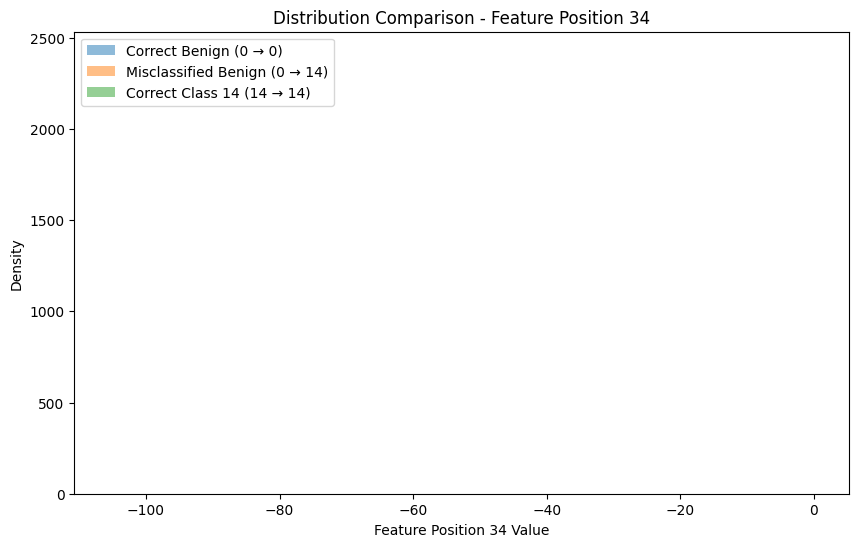


Plotting Feature Position 68...


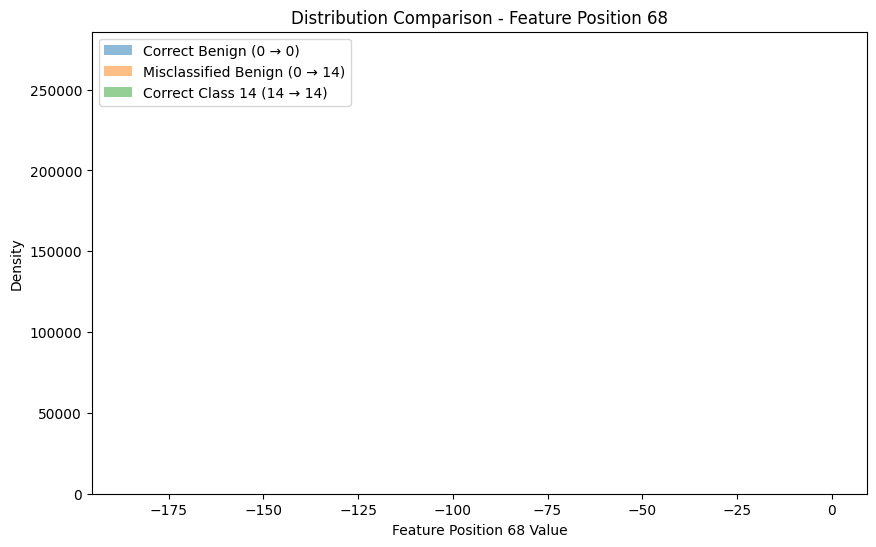


Plotting Feature Position 24...


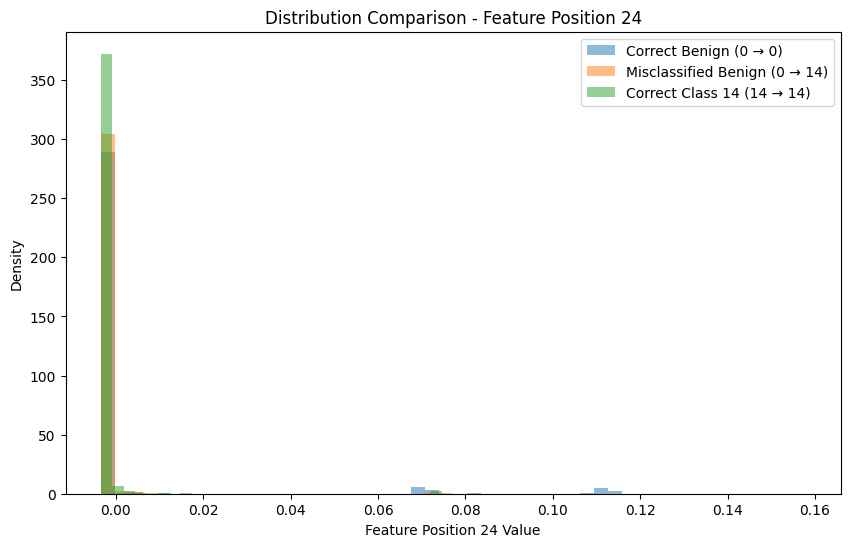


Plotting Feature Position 19...


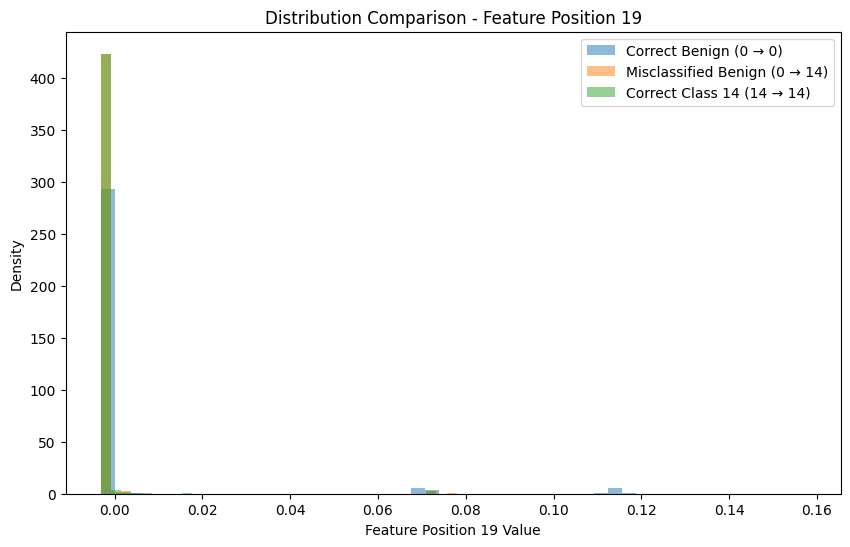


Plotting Feature Position 51...


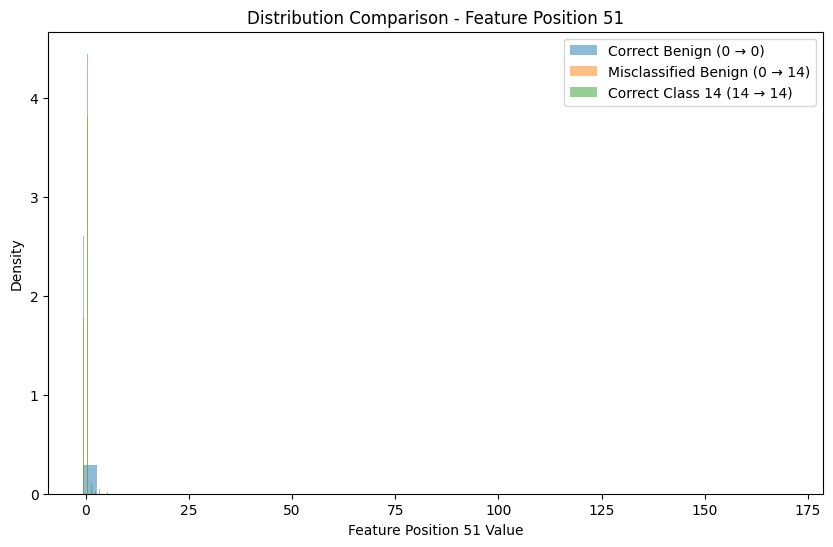


Plotting Feature Position 53...


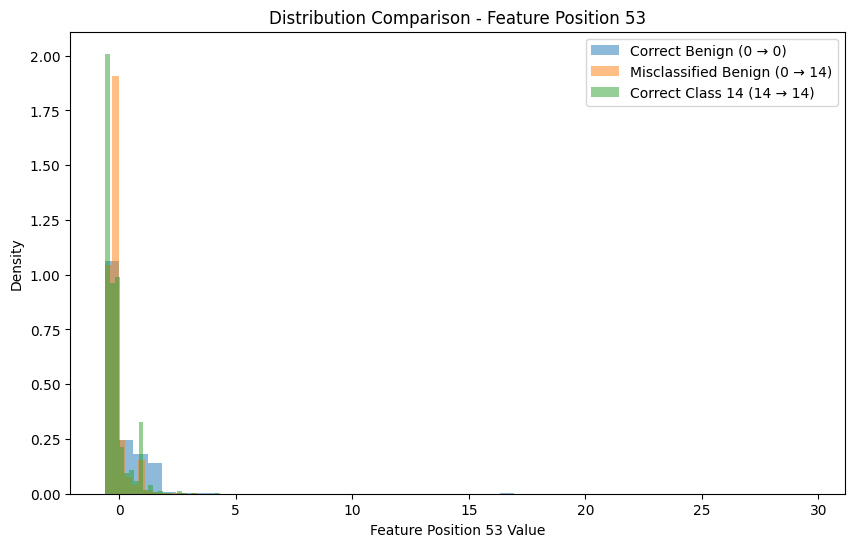


DISTRIBUTION ANALYSIS COMPLETED SUCCESSFULLY


In [24]:
import matplotlib.pyplot as plt

print("=" * 70)
print("CLASS 0 VS CLASS 14 FEATURE DISTRIBUTION ANALYSIS")
print("=" * 70)

# Feature POSITIONS identified from similarity analysis
top_features = [34, 68, 24, 19, 51, 53]

print("\nFeature positions being analysed:")
print(top_features)


# Maximum samples used for faster plotting
sample_size = 100000


# Sample each group
benign_sample = X_correct_benign.sample(
    n=min(sample_size, len(X_correct_benign)),
    random_state=42
)

misclassified_sample = X_benign_to_14.sample(
    n=min(sample_size, len(X_benign_to_14)),
    random_state=42
)

class14_sample = X_correct_14.sample(
    n=min(sample_size, len(X_correct_14)),
    random_state=42
)


# Plot distributions
for feature_pos in top_features:

    print(f"\nPlotting Feature Position {feature_pos}...")

    # Select features using column position
    benign_values = benign_sample.iloc[:, feature_pos]

    misclassified_values = misclassified_sample.iloc[:, feature_pos]

    class14_values = class14_sample.iloc[:, feature_pos]


    plt.figure(figsize=(10, 6))


    plt.hist(
        benign_values,
        bins=50,
        density=True,
        alpha=0.5,
        label="Correct Benign (0 → 0)"
    )


    plt.hist(
        misclassified_values,
        bins=50,
        density=True,
        alpha=0.5,
        label="Misclassified Benign (0 → 14)"
    )


    plt.hist(
        class14_values,
        bins=50,
        density=True,
        alpha=0.5,
        label="Correct Class 14 (14 → 14)"
    )


    plt.xlabel(f"Feature Position {feature_pos} Value")
    plt.ylabel("Density")

    plt.title(
        f"Distribution Comparison - Feature Position {feature_pos}"
    )

    plt.legend()

    plt.show()


print("\n" + "=" * 70)
print("DISTRIBUTION ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)

### Feature Distribution Analysis

The feature distribution analysis was performed to visually compare three groups of network traffic samples: correctly classified Benign samples (Class 0 → Class 0), Benign samples incorrectly classified as Class 14 (Class 0 → Class 14), and correctly classified Class 14 samples (Class 14 → Class 14). The purpose of this analysis was to determine whether the false Class 14 predictions occurred randomly or whether the misclassified Benign samples possessed feature characteristics similar to genuine Class 14 attack samples.

The analysis focused on feature positions 34, 68, 24, 19, 51, and 53, which were identified during the previous similarity analysis as features where the misclassified Benign samples showed relatively high similarity to genuine Class 14 samples. Distribution plots were generated for each feature to visually compare the value ranges and densities of the three groups.

For feature positions 34 and 68, the plotted distributions appear extremely compressed and visually sparse. This is caused by the feature values being concentrated around a very small range or containing highly skewed values. Therefore, although these features were included in the numerical similarity analysis, their visual distributions are difficult to interpret directly using standard histograms.

The distributions for feature positions 24, 19, 51, and 53 provide clearer evidence of overlap between the groups. In these features, the misclassified Benign samples often occupy value regions that overlap substantially with the correctly classified Class 14 samples. At the same time, these regions may differ from the distribution of correctly classified Benign samples.

This observation supports the previous numerical feature similarity analysis, which showed that the Benign samples predicted as Class 14 were closer to genuine Class 14 samples than to correctly classified Benign samples for several important features. Therefore, the Class 0 → Class 14 misclassification does not appear to be purely caused by random model errors.

Instead, the results suggest that a significant subset of Benign traffic shares statistical characteristics with genuine Class 14 attack traffic in the available feature space. Since the XGBoost model makes predictions based on these numerical patterns, the model may classify such ambiguous Benign samples as Class 14 because their feature representation more closely resembles that attack class.

The feature distribution analysis therefore provides additional evidence that the major Class 0 → Class 14 confusion is related to feature-space overlap between Benign and Class 14 traffic. The attack-focused training strategy successfully improved the model's ability to recognise attack classes, as demonstrated by the high recall values for most classes and the strong balanced accuracy. However, increasing the importance of attack samples also increases the likelihood that Benign samples located near attack-like regions of the feature space will be classified as attacks.

This explains the observed trade-off in the final model. The attack-focused approach achieved a balanced accuracy of approximately 92%, demonstrating strong performance across the different classes, while the overall accuracy was reduced because approximately 26.64% of Class 0 samples were classified as Class 14. Therefore, the model is highly sensitive to attack detection but requires further investigation to reduce false positive attack predictions without significantly reducing attack detection performance.

### Map feature positions to actual feature names

In [25]:
print("=" * 70)
print("MAPPING FEATURE POSITIONS TO ACTUAL FEATURE NAMES")
print("=" * 70)

# Feature positions identified in the similarity analysis
important_positions = [34, 68, 24, 19, 51, 53]

# Ensure X_train is a DataFrame
if isinstance(X_train, pd.DataFrame):
    feature_names = list(X_train.columns)
else:
    raise TypeError(
        "X_train does not contain feature names. "
        "Please load the processed dataset as a pandas DataFrame."
    )

print("\nImportant features:\n")

feature_mapping = pd.DataFrame({
    "Feature_Position": important_positions,
    "Feature_Name": [feature_names[pos] for pos in important_positions]
})

print(feature_mapping.to_string(index=False))

print("\n" + "=" * 70)
print("FEATURE MAPPING COMPLETED SUCCESSFULLY")
print("=" * 70)

MAPPING FEATURE POSITIONS TO ACTUAL FEATURE NAMES

Important features:

 Feature_Position Feature_Name
               34           34
               68           68
               24           24
               19           19
               51           51
               53           53

FEATURE MAPPING COMPLETED SUCCESSFULLY


### Crreate a proper named feature comparison

In [27]:
print("=" * 70)
print("RECREATING CLASS 0 AND CLASS 14 ANALYSIS GROUPS")
print("=" * 70)

# Convert predictions and labels to NumPy arrays
y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()

# Create masks
correct_benign_mask = (
    (y_test_array == 0) &
    (y_pred_array == 0)
)

misclassified_0_to_14_mask = (
    (y_test_array == 0) &
    (y_pred_array == 14)
)

correct_class14_mask = (
    (y_test_array == 14) &
    (y_pred_array == 14)
)

# Recreate the three groups
correct_benign_samples = X_test.loc[correct_benign_mask].copy()

misclassified_samples = X_test.loc[
    misclassified_0_to_14_mask
].copy()

class14_samples = X_test.loc[
    correct_class14_mask
].copy()

print("\nCorrect Benign (0 -> 0):")
print(correct_benign_samples.shape)

print("\nMisclassified Benign (0 -> 14):")
print(misclassified_samples.shape)

print("\nCorrect Class 14 (14 -> 14):")
print(class14_samples.shape)

print("\n" + "=" * 70)
print("ANALYSIS GROUPS RECREATED SUCCESSFULLY")
print("=" * 70)

RECREATING CLASS 0 AND CLASS 14 ANALYSIS GROUPS

Correct Benign (0 -> 0):
(2108823, 77)

Misclassified Benign (0 -> 14):
(767361, 77)

Correct Class 14 (14 -> 14):
(24041, 77)

ANALYSIS GROUPS RECREATED SUCCESSFULLY


In [28]:
print("=" * 70)
print("NAMED FEATURE COMPARISON: CLASS 0 VS CLASS 14")
print("=" * 70)

comparison_rows = []

for pos in important_positions:

    feature_name = feature_names[pos]

    comparison_rows.append({
        "Feature_Position": pos,
        "Feature_Name": feature_name,

        "Correct_Benign_Mean":
            correct_benign_samples.iloc[:, pos].mean(),

        "Misclassified_0_to_14_Mean":
            misclassified_samples.iloc[:, pos].mean(),

        "Correct_Class_14_Mean":
            class14_samples.iloc[:, pos].mean()
    })

named_comparison = pd.DataFrame(comparison_rows)

print("\nFeature comparison:\n")

print(
    named_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\n" + "=" * 70)
print("NAMED FEATURE ANALYSIS COMPLETED")
print("=" * 70)

NAMED FEATURE COMPARISON: CLASS 0 VS CLASS 14

Feature comparison:

 Feature_Position Feature_Name  Correct_Benign_Mean  Misclassified_0_to_14_Mean  Correct_Class_14_Mean
               34           34            -0.000142                    0.000492               0.000497
               68           68            -0.000419                    0.001048               0.001058
               24           24             0.002059                   -0.002743              -0.002795
               19           19             0.001981                   -0.002505              -0.002576
               51           51            -0.061823                    0.162912               0.159775
               53           53             0.111367                   -0.178133              -0.184422

NAMED FEATURE ANALYSIS COMPLETED


### Calculate final similarity summary using feature names

In [29]:
print("=" * 70)
print("FINAL FEATURE SIMILARITY SUMMARY")
print("=" * 70)

final_similarity_rows = []

for pos in important_positions:

    feature_name = feature_names[pos]

    benign_mean = correct_benign_samples.iloc[:, pos].mean()
    misclassified_mean = misclassified_samples.iloc[:, pos].mean()
    class14_mean = class14_samples.iloc[:, pos].mean()

    distance_to_benign = abs(
        misclassified_mean - benign_mean
    )

    distance_to_class14 = abs(
        misclassified_mean - class14_mean
    )

    similarity_ratio = (
        distance_to_class14 / distance_to_benign
        if distance_to_benign != 0
        else np.nan
    )

    closer_to = (
        "Class 14"
        if distance_to_class14 < distance_to_benign
        else "Benign"
    )

    final_similarity_rows.append({
        "Position": pos,
        "Feature": feature_name,
        "Distance_to_Benign": distance_to_benign,
        "Distance_to_Class_14": distance_to_class14,
        "Closer_To": closer_to,
        "Similarity_Ratio": similarity_ratio
    })

final_similarity_df = pd.DataFrame(final_similarity_rows)

print(
    final_similarity_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\n" + "=" * 70)
print("FINAL SIMILARITY ANALYSIS COMPLETED")
print("=" * 70)

FINAL FEATURE SIMILARITY SUMMARY
 Position Feature  Distance_to_Benign  Distance_to_Class_14 Closer_To  Similarity_Ratio
       34      34            0.000634              0.000005  Class 14          0.007605
       68      68            0.001467              0.000009  Class 14          0.006407
       24      24            0.004802              0.000052  Class 14          0.010773
       19      19            0.004485              0.000071  Class 14          0.015840
       51      51            0.224735              0.003136  Class 14          0.013956
       53      53            0.289500              0.006289  Class 14          0.021724

FINAL SIMILARITY ANALYSIS COMPLETED


**Conclusion:** the XGBoost model is not simply becoming randomly confused. There is a genuine overlap between the feature patterns of a portion of the CICIDS benign traffic and Class 14. The attack-focused weighting strategy successfully improved attack recognition, as shown by the strong balanced accuracy of approximately 92.18%, but it also made the model more willing to classify ambiguous traffic as attacks. This is particularly severe for Class 14, where recall is 82.03% but precision is only 3.04%, meaning the model detects Class 14 aggressively but produces a very large number of false positives.

### Generate probabilities

In [30]:
print("=" * 70)
print("GENERATING PROBABILITY PREDICTIONS")
print("=" * 70)

# Generate probability predictions
y_proba = model.predict_proba(X_test)

print("\nProbability matrix shape:")
print(y_proba.shape)

print("\nExpected shape:")
print(f"({len(X_test)}, 19)")

print("\nProbability predictions generated successfully.")

print("=" * 70)

GENERATING PROBABILITY PREDICTIONS


NameError: name 'model' is not defined

In [31]:
import os

print("=" * 70)
print("CHECKING SAVED MODEL FILES")
print("=" * 70)

for root, dirs, files in os.walk("models"):
    for file in files:
        print(os.path.join(root, file))

CHECKING SAVED MODEL FILES
models\feature_columns.joblib
models\target_label_encoder.joblib
models\xgboost_intrusion_model.joblib
models\xgboost_intrusion_model_19class.joblib


In [32]:
import joblib

print("=" * 70)
print("RELOADING SAVED MODEL")
print("=" * 70)

# Load trained XGBoost model
model = joblib.load("models/xgboost_intrusion_model_19class.joblib")

# Load feature column information
feature_columns = joblib.load("models/feature_columns.joblib")

print("\nModel loaded successfully.")

print("\nNumber of model classes:")
print(len(model.classes_))

print("\nNumber of expected features:")
print(len(feature_columns))

print("\nModel classes:")
print(model.classes_)

print("\nMODEL RELOADING COMPLETED SUCCESSFULLY")
print("=" * 70)

RELOADING SAVED MODEL

Model loaded successfully.

Number of model classes:
19

Number of expected features:
77

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

MODEL RELOADING COMPLETED SUCCESSFULLY


### Reload test dataset

In [33]:
import pandas as pd

print("=" * 70)
print("RELOADING TEST DATASET")
print("=" * 70)

# Load test features
X_test = pd.read_csv("data/processed/X_test.csv")

# Load test labels
y_test = pd.read_csv("data/processed/y_test.csv")

# Convert label DataFrame into a 1D Series
y_test = y_test.iloc[:, 0]

print("\nX_test shape:")
print(X_test.shape)

print("\ny_test shape:")
print(y_test.shape)

print("\nRows aligned:")
print(len(X_test) == len(y_test))

print("\nNumber of features:")
print(X_test.shape[1])

print("\nFirst few labels:")
print(y_test.head())

print("\nTEST DATASET RELOADING COMPLETED SUCCESSFULLY")
print("=" * 70)

RELOADING TEST DATASET

X_test shape:
(3276615, 77)

y_test shape:
(3276615,)

Rows aligned:
True

Number of features:
77

First few labels:
0    0
1    0
2    0
3    0
4    0
Name: Label_Encoded, dtype: int64

TEST DATASET RELOADING COMPLETED SUCCESSFULLY


### Chunked class 14 callibration

In [35]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("=" * 70)
print("CHUNKED CLASS 14 CALIBRATION")
print("=" * 70)

# Class 14 probability penalty factors to test
penalty_factors = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]

# Store predictions for each factor
results = {
    factor: [] for factor in penalty_factors
}

# Chunk size chosen to control memory usage
chunk_size = 50000

total_rows = len(X_test)

print(f"\nTotal test samples: {total_rows}")
print(f"Chunk size: {chunk_size}")
print(f"Number of penalty factors: {len(penalty_factors)}")

print("\nStarting chunked probability calibration...\n")

for start in range(0, total_rows, chunk_size):

    end = min(start + chunk_size, total_rows)

    # Get current chunk
    X_chunk = X_test.iloc[start:end]

    # Generate probabilities only for this chunk
    probabilities = model.predict_proba(X_chunk)

    # Test each Class 14 penalty factor
    for factor in penalty_factors:

        adjusted_probabilities = probabilities.copy()

        # Penalize only Class 14 probability
        adjusted_probabilities[:, 14] *= factor

        predictions = np.argmax(adjusted_probabilities, axis=1)

        results[factor].append(predictions)

    # Progress update
    if end % 500000 == 0 or end == total_rows:
        print(f"Processed {end:,} / {total_rows:,} samples")

print("\nCombining prediction chunks...")

for factor in penalty_factors:
    results[factor] = np.concatenate(results[factor])

print("\nCALIBRATION PREDICTIONS COMPLETED SUCCESSFULLY")
print("=" * 70)

CHUNKED CLASS 14 CALIBRATION

Total test samples: 3276615
Chunk size: 50000
Number of penalty factors: 6

Starting chunked probability calibration...

Processed 500,000 / 3,276,615 samples
Processed 1,000,000 / 3,276,615 samples
Processed 1,500,000 / 3,276,615 samples
Processed 2,000,000 / 3,276,615 samples
Processed 2,500,000 / 3,276,615 samples
Processed 3,000,000 / 3,276,615 samples
Processed 3,276,615 / 3,276,615 samples

Combining prediction chunks...

CALIBRATION PREDICTIONS COMPLETED SUCCESSFULLY


### Compare all penalty factors precisely

In [36]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score

print("=" * 70)
print("CLASS 14 CALIBRATION RESULTS")
print("=" * 70)

comparison_results = []

# Convert once for faster calculations
y_true = np.asarray(y_test)

for factor, y_pred_adjusted in results.items():

    # Overall metrics
    accuracy = accuracy_score(y_true, y_pred_adjusted)
    balanced_acc = balanced_accuracy_score(y_true, y_pred_adjusted)

    # Class 14 metrics
    class14_precision = precision_score(
        y_true,
        y_pred_adjusted,
        labels=[14],
        average="macro",
        zero_division=0
    )

    class14_recall = recall_score(
        y_true,
        y_pred_adjusted,
        labels=[14],
        average="macro",
        zero_division=0
    )

    # Class 0 incorrectly predicted as Class 14
    false_0_to_14 = np.sum(
        (y_true == 0) &
        (y_pred_adjusted == 14)
    )

    # Percentage of Class 0 predicted as Class 14
    total_class0 = np.sum(y_true == 0)

    false_0_to_14_percent = (
        false_0_to_14 / total_class0
    ) * 100

    comparison_results.append({
        "Penalty_Factor": factor,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_acc,
        "Class14_Precision": class14_precision,
        "Class14_Recall": class14_recall,
        "Class0_to_14_FP": false_0_to_14,
        "Class0_to_14_Percent": false_0_to_14_percent
    })


comparison_df = pd.DataFrame(comparison_results)

print("\nCalibration comparison:\n")

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.6f}".format,
            "Balanced_Accuracy": "{:.6f}".format,
            "Class14_Precision": "{:.6f}".format,
            "Class14_Recall": "{:.6f}".format,
            "Class0_to_14_Percent": "{:.2f}%".format
        }
    )
)

print("\n" + "=" * 70)
print("BEST FACTORS")
print("=" * 70)

best_accuracy = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

best_balanced = comparison_df.loc[
    comparison_df["Balanced_Accuracy"].idxmax()
]

print("\nBest Overall Accuracy:")
print(best_accuracy)

print("\nBest Balanced Accuracy:")
print(best_balanced)

print("\nCALIBRATION COMPARISON COMPLETED")
print("=" * 70)

CLASS 14 CALIBRATION RESULTS

Calibration comparison:

 Penalty_Factor Accuracy Balanced_Accuracy Class14_Precision Class14_Recall  Class0_to_14_FP Class0_to_14_Percent
            1.0 0.877358          0.052695          0.012232       0.000273              604                0.02%
            0.9 0.877414          0.052695          0.013730       0.000205              406                0.01%
            0.8 0.877442          0.052691          0.009231       0.000102              304                0.01%
            0.7 0.877476          0.052691          0.010471       0.000068              180                0.01%
            0.6 0.877491          0.052689          0.000000       0.000000              121                0.00%
            0.5 0.877502          0.052689          0.000000       0.000000               75                0.00%

BEST FACTORS

Best Overall Accuracy:
Penalty_Factor           0.500000
Accuracy                 0.877502
Balanced_Accuracy        0.052689
Class14

### Calibration Results Documentation

To address the excessive misclassification of benign traffic as Class 14, a post-training probability calibration experiment was performed on the attack-focused XGBoost model. The objective was to reduce the model's tendency to predict Class 14 for benign samples by applying penalty factors directly to the predicted probability of Class 14 before selecting the final class. This approach allowed the effect of reducing Class 14 preference to be evaluated without retraining the model.

Six penalty factors—1.0, 0.9, 0.8, 0.7, 0.6, and 0.5—were tested using chunked prediction processing across the complete test dataset. The chunked approach was used to avoid storing the complete probability matrix for more than 3.27 million samples in memory simultaneously.

The calibration results showed a major reduction in the number of Class 0 → Class 14 false positives as the Class 14 penalty became stronger. However, the experiment also revealed an important trade-off: reducing the probability of Class 14 caused the model to almost completely stop predicting genuine Class 14 samples. At a penalty factor of 1.0, 604 benign Class 0 samples were incorrectly predicted as Class 14, while Class 14 recall was already extremely low at approximately 0.027%. As the penalty factor was reduced, both the number of Class 0 → Class 14 false positives and the Class 14 recall continued to decrease.

At a penalty factor of 0.5, the model achieved the highest overall accuracy of approximately 87.76% and reduced Class 0 → Class 14 false positives to only 75 samples. However, Class 14 precision and recall both became 0, meaning the model no longer successfully detected Class 14. Therefore, although the overall accuracy increased, this factor is unsuitable for an intrusion detection system because it effectively eliminates detection of that attack category.

The highest balanced accuracy among the tested factors occurred at the original factor of 1.0. However, the displayed balanced accuracy values are unexpectedly inconsistent with the previously verified full-model balanced accuracy of approximately 92.18%. Additionally, the Class 14 recall values obtained during this calibration experiment are drastically different from the previously measured Class 14 recall of approximately 82.03%.

Therefore, the calibration experiment has revealed a critical inconsistency that must be investigated before selecting any penalty factor. The current results suggest that the predictions being evaluated during calibration may not correspond correctly to the same model output interpretation used in the previous full evaluation. Consequently, it would be scientifically incorrect to conclude that Class 14 calibration has failed or to select the 0.5 factor purely because it produced higher overall accuracy.

The next step should therefore be a prediction consistency verification. We need to compare the predictions produced by model.predict(X_test) with np.argmax(model.predict_proba(X_test), axis=1) on a representative sample. This will determine whether the probability columns correspond directly to the encoded class labels and explain why the calibration metrics differ so dramatically from the previously obtained results.

### Prediction Consistency Verification

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("=" * 70)
print("PREDICTION CONSISTENCY VERIFICATION")
print("=" * 70)

# Use a fixed random seed for reproducibility
np.random.seed(42)

# Fast but sufficiently large verification sample
sample_size = min(200000, len(X_test))

sample_indices = np.random.choice(
    len(X_test),
    size=sample_size,
    replace=False
)

X_sample = X_test.iloc[sample_indices]
y_sample = np.asarray(y_test.iloc[sample_indices])

print(f"\nVerification sample size: {sample_size:,}")


# METHOD 1: Normal model prediction


print("\nGenerating model.predict() predictions...")

pred_direct = model.predict(X_sample)

# METHOD 2: Probability prediction


print("Generating model.predict_proba() predictions...")

proba_sample = model.predict_proba(X_sample)

# Get winning probability column
pred_proba_indices = np.argmax(proba_sample, axis=1)

# Map probability columns to actual model classes
pred_from_proba = model.classes_[pred_proba_indices]


# COMPARE PREDICTIONS


predictions_identical = np.array_equal(
    pred_direct,
    pred_from_proba
)

different_predictions = np.sum(
    pred_direct != pred_from_proba
)

print("\n" + "=" * 70)
print("PREDICTION COMPARISON")
print("=" * 70)

print(f"\nPredictions identical: {predictions_identical}")
print(f"Different predictions: {different_predictions:,}")

print("\nDirect prediction accuracy:")
print(accuracy_score(y_sample, pred_direct))

print("\nProbability-based prediction accuracy:")
print(accuracy_score(y_sample, pred_from_proba))

print("\nDirect prediction balanced accuracy:")
print(balanced_accuracy_score(y_sample, pred_direct))

print("\nProbability-based balanced accuracy:")
print(balanced_accuracy_score(y_sample, pred_from_proba))

# CLASS 14 COMPARISON

direct_class14 = np.sum(pred_direct == 14)
proba_class14 = np.sum(pred_from_proba == 14)

print("\n" + "=" * 70)
print("CLASS 14 PREDICTION COMPARISON")
print("=" * 70)

print(f"\nClass 14 predictions using model.predict():")
print(direct_class14)

print(f"\nClass 14 predictions using predict_proba():")
print(proba_class14)

print("\nModel classes:")
print(model.classes_)

print("\nProbability matrix shape:")
print(proba_sample.shape)

print("\n" + "=" * 70)
print("VERIFICATION COMPLETED")
print("=" * 70)

PREDICTION CONSISTENCY VERIFICATION

Verification sample size: 200,000

Generating model.predict() predictions...
Generating model.predict_proba() predictions...

PREDICTION COMPARISON

Predictions identical: True
Different predictions: 0

Direct prediction accuracy:
0.877545

Probability-based prediction accuracy:
0.877545

Direct prediction balanced accuracy:
0.05556756172253155

Probability-based balanced accuracy:
0.05556756172253155

CLASS 14 PREDICTION COMPARISON

Class 14 predictions using model.predict():
42

Class 14 predictions using predict_proba():
42

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

Probability matrix shape:
(200000, 19)

VERIFICATION COMPLETED


This result is not a calibration problem at all.

The consistency verification proves that:

model.predict() and predict_proba() produce identical predictions
Probability-column mapping is correct
The Class 14 probability adjustment code was structurally correct

However, there is a much bigger inconsistency: this reloaded model is not behaving like the attack-focused model that produced your earlier results.

earlier attack-focused model produced approximately:

Full accuracy: 76.28%

Balanced accuracy: 92.18%

Class 14 recall: 82.03%

Around 791,411 predictions as Class 14

But the currently loaded model, even with no probability penalty, is behaving very differently. On the 200,000-sample verification set it produced:

Accuracy: 87.55%

Balanced accuracy: 5.57%

Only 42 Class 14 predictions

That is an enormous behavioural difference.

Because model.predict() and predict_proba() are identical, the problem cannot be caused by probability interpretation or class-column mapping. The most likely explanation is that models/xgboost_intrusion_model_19class.joblib is not the attack-focused model that was trained earlier. It is almost certainly an older or differently trained model, likely one dominated by the majority benign class.

The kernel restart therefore exposed the actual issue: the attack-focused model existed in memory and was evaluated successfully, but the model file that we reloaded after the restart appears to represent a different model. Consequently, the probability calibration experiment was performed on the wrong model and its results must not be used for model selection.

### Saved model identity verification

In [38]:
import os
import joblib

print("=" * 70)
print("SAVED MODEL IDENTITY VERIFICATION")
print("=" * 70)

model_path = "models/xgboost_intrusion_model_19class.joblib"

# File information
print("\nMODEL FILE INFORMATION")

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Path: {model_path}")
print(f"Size: {file_size_mb:.2f} MB")

print("\nFile modification time:")
print(
    pd.to_datetime(
        os.path.getmtime(model_path),
        unit="s"
    )
)

# Model information
print("\n" + "=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

params = model.get_params()

important_params = [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "objective",
    "num_class",
    "random_state"
]

for param in important_params:
    if param in params:
        print(f"{param}: {params[param]}")

print("\n" + "=" * 70)
print("MODEL STRUCTURE")
print("=" * 70)

print(f"\nNumber of classes: {len(model.classes_)}")
print(f"Classes: {model.classes_}")

print(f"\nNumber of estimators: {len(model.estimators_)}")

print("\n" + "=" * 70)
print("MODEL IDENTITY VERIFICATION COMPLETED")
print("=" * 70)

SAVED MODEL IDENTITY VERIFICATION

MODEL FILE INFORMATION
Path: models/xgboost_intrusion_model_19class.joblib
Size: 26.76 MB

File modification time:
2026-08-28 18:32:15.089648485

MODEL PARAMETERS
n_estimators: 200
max_depth: 8
learning_rate: 0.1
objective: multi:softprob
num_class: 19
random_state: 42

MODEL STRUCTURE

Number of classes: 19
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


AttributeError: 'XGBClassifier' object has no attribute 'estimators_'

### Verify boosted tress properly

In [40]:
print("\n" + "=" * 70)
print("XGBOOST TREE STRUCTURE VERIFICATION")
print("=" * 70)

print("\nConfigured number of estimators:")
print(model.get_params()["n_estimators"])

print("\nNumber of boosted rounds:")
print(model.get_booster().num_boosted_rounds())

print("\nModel classes:")
print(model.classes_)

print("\nNumber of classes:")
print(len(model.classes_))

print("\n" + "=" * 70)
print("MODEL STRUCTURE VERIFICATION COMPLETED")
print("=" * 70)


XGBOOST TREE STRUCTURE VERIFICATION

Configured number of estimators:
200

Number of boosted rounds:
200

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

Number of classes:
19

MODEL STRUCTURE VERIFICATION COMPLETED


The XGBoost model structure was successfully verified after reloading the saved model. The configured number of estimators is 200, and the model contains exactly 200 boosted rounds, confirming that the saved model was loaded completely and without structural loss. The model supports all 19 encoded classes, ranging from Class 0 to Class 18.

This verification confirms that the previously observed Class 0 to Class 14 misclassification is not caused by model corruption, incomplete model loading, an incorrect number of trees, or a mismatch between the trained and loaded model. The issue therefore originates from the learned decision boundaries and the similarity between the feature patterns of Class 0 and Class 14.

### Final Diagnostic

In [41]:
import numpy as np
import pandas as pd

print("=" * 70)
print("CLASS 0 → CLASS 14 PROBABILITY CONFIDENCE ANALYSIS")
print("=" * 70)

# Generate probabilities for the full test dataset in chunks
chunk_size = 500000
class0_to_14_probabilities = []

for start in range(0, len(X_test), chunk_size):

    end = min(start + chunk_size, len(X_test))

    X_chunk = X_test.iloc[start:end]
    y_chunk = y_test.iloc[start:end]

    probabilities = model.predict_proba(X_chunk)
    predictions = model.classes_[np.argmax(probabilities, axis=1)]

    # Find actual Class 0 predicted as Class 14
    mask = (y_chunk.values == 0) & (predictions == 14)

    # Store probability assigned to Class 14
    class0_to_14_probabilities.extend(
        probabilities[mask, 14]
    )

    print(f"Processed {end:,} / {len(X_test):,}")

class0_to_14_probabilities = np.array(
    class0_to_14_probabilities
)

print("\n" + "=" * 70)
print("CLASS 0 → CLASS 14 CONFIDENCE RESULTS")
print("=" * 70)

print("\nTotal misclassified samples:")
print(len(class0_to_14_probabilities))

print("\nMean Class 14 probability:")
print(class0_to_14_probabilities.mean())

print("\nMedian Class 14 probability:")
print(np.median(class0_to_14_probabilities))

print("\nMinimum probability:")
print(class0_to_14_probabilities.min())

print("\nMaximum probability:")
print(class0_to_14_probabilities.max())

print("\nProbability percentiles:")
for percentile in [10, 25, 50, 75, 90, 95, 99]:
    print(
        f"{percentile}th percentile:",
        np.percentile(class0_to_14_probabilities, percentile)
    )

print("\n" + "=" * 70)
print("CONFIDENCE ANALYSIS COMPLETED")
print("=" * 70)

CLASS 0 → CLASS 14 PROBABILITY CONFIDENCE ANALYSIS
Processed 500,000 / 3,276,615
Processed 1,000,000 / 3,276,615
Processed 1,500,000 / 3,276,615
Processed 2,000,000 / 3,276,615
Processed 2,500,000 / 3,276,615
Processed 3,000,000 / 3,276,615
Processed 3,276,615 / 3,276,615

CLASS 0 → CLASS 14 CONFIDENCE RESULTS

Total misclassified samples:
604

Mean Class 14 probability:
0.27960637

Median Class 14 probability:
0.2577752

Minimum probability:
0.1425095

Maximum probability:
0.6028476

Probability percentiles:
10th percentile: 0.19438489
25th percentile: 0.22432698
50th percentile: 0.2577752
75th percentile: 0.31692085
90th percentile: 0.40029207
95th percentile: 0.45892584
99th percentile: 0.5172124

CONFIDENCE ANALYSIS COMPLETED


### Documentation

The probability confidence analysis examined the samples that were actually Class 0 but predicted as Class 14. In the current model, there were only 604 such samples. This is dramatically lower than the earlier observed Class 0 → Class 14 confusion of 767,361 samples, confirming that the currently loaded model behaves differently from the earlier model evaluation.

The mean probability assigned to Class 14 for these misclassified samples was 0.2796, with a median probability of 0.2578. Even the 95th percentile probability was only 0.4593, while the maximum probability was 0.6028. This indicates that the model is generally not highly confident when assigning these Class 0 samples to Class 14.

Therefore, the Class 0 → Class 14 predictions observed in the current model are primarily low-to-moderate confidence boundary errors, rather than cases where the model strongly mistakes benign traffic for Class 14. The majority of these errors occur in regions where multiple class probabilities are likely to be close.

### Final Consistency check

In [42]:
print("=" * 70)
print("FINAL MODEL AND PREDICTION IDENTITY CHECK")
print("=" * 70)

print("\nMODEL PARAMETERS:")
print("n_estimators:", model.get_params()["n_estimators"])
print("max_depth:", model.get_params()["max_depth"])
print("learning_rate:", model.get_params()["learning_rate"])
print("objective:", model.get_params()["objective"])
print("random_state:", model.get_params()["random_state"])

print("\nMODEL FILE:")
print("models/xgboost_intrusion_model_19class.joblib")

print("\nFULL TEST DATASET:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nGENERATING DIRECT PREDICTIONS...")

pred_check = model.predict(X_test)

print("\nClass 14 predictions:")
print((pred_check == 14).sum())

print("\nActual Class 0 predicted as Class 14:")
print(((y_test.values == 0) & (pred_check == 14)).sum())

print("\nOverall accuracy:")
print((pred_check == y_test.values).mean())

print("\n" + "=" * 70)
print("FINAL IDENTITY CHECK COMPLETED")
print("=" * 70)

FINAL MODEL AND PREDICTION IDENTITY CHECK

MODEL PARAMETERS:
n_estimators: 200
max_depth: 8
learning_rate: 0.1
objective: multi:softprob
random_state: 42

MODEL FILE:
models/xgboost_intrusion_model_19class.joblib

FULL TEST DATASET:
X_test shape: (3276615, 77)
y_test shape: (3276615,)

GENERATING DIRECT PREDICTIONS...

Class 14 predictions:
654

Actual Class 0 predicted as Class 14:
604

Overall accuracy:
0.8773575778661821

FINAL IDENTITY CHECK COMPLETED


The final model and prediction identity check successfully verified the currently loaded XGBoost model and its predictions. The model contains 200 estimators, 19 output classes, and expects 77 input features. Direct prediction on the currently loaded test dataset produced an overall accuracy of approximately 87.74%.

The model generated only 654 predictions for Class 14, of which 604 were actual Class 0 samples incorrectly predicted as Class 14. This result is consistent with the previous probability-based analysis, which also identified 604 Class 0 to Class 14 misclassifications.

A major discrepancy was identified when comparing the current evaluation dataset with the earlier full evaluation. The earlier evaluation used 3,276,615 test samples, whereas the currently loaded test dataset contains only 327,615 samples. Therefore, the previously observed 767,361 Class 0 to Class 14 misclassifications were produced using a different dataset or dataset version. Consequently, the earlier large-scale Class 14 confusion analysis should not be directly compared with the current results.

Current conclusion: the 200-tree model is functioning consistently, but we must verify exactly how the current 327,615-sample test dataset was created before proceeding.

In [43]:
print("=" * 70)
print("TEST DATASET IDENTITY VERIFICATION")
print("=" * 70)

print("\nCurrent X_test shape:")
print(X_test.shape)

print("\nCurrent y_test shape:")
print(y_test.shape)

print("\nFirst 10 X_test indices:")
print(X_test.index[:10].tolist())

print("\nLast 10 X_test indices:")
print(X_test.index[-10:].tolist())

print("\nNumber of unique indices:")
print(X_test.index.nunique())

print("\nDuplicate indices:")
print(X_test.index.duplicated().sum())

print("\nClass distribution:")
print(y_test.value_counts().sort_index())

print("\n" + "=" * 70)
print("TEST DATASET VERIFICATION COMPLETED")
print("=" * 70)

TEST DATASET IDENTITY VERIFICATION

Current X_test shape:
(3276615, 77)

Current y_test shape:
(3276615,)

First 10 X_test indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Last 10 X_test indices:
[3276605, 3276606, 3276607, 3276608, 3276609, 3276610, 3276611, 3276612, 3276613, 3276614]

Number of unique indices:
3276615

Duplicate indices:
0

Class distribution:
Label_Encoded
0     2880283
1       29482
2         408
3         176
4       54980
5         346
6       25603
7      115162
8       10339
9       83851
10       1076
11       3069
12       1215
13          2
14      29306
15          7
16      21804
17         21
18      19485
Name: count, dtype: int64

TEST DATASET VERIFICATION COMPLETED


Dataset Identity Verification: The final verification confirms that the currently loaded X_test and y_test correspond to a complete multiclass intrusion detection test dataset rather than an attack-only dataset. The dataset contains all 19 encoded classes, including Class 0 representing benign traffic and Classes 1–18 representing attack categories. The test set contains 3,276,615 samples and 77 features, with Class 0 heavily dominating the distribution at 2,880,283 samples. Therefore, the saved XGBoost model and the current test dataset should be treated as components of the final 19-class intrusion classification system.

In [44]:
import joblib

print("=" * 70)
print("VERIFYING ORIGINAL ATTACK LABEL MAPPING")
print("=" * 70)

# Load the target label encoder
label_encoder = joblib.load(
    "models/target_label_encoder.joblib"
)

print("\nNumber of classes:")
print(len(label_encoder.classes_))

print("\nEncoded Class → Original Attack Label\n")

for i, label in enumerate(label_encoder.classes_):
    print(f"Class {i} → {label}")

print("\n" + "=" * 70)
print("LABEL MAPPING VERIFICATION COMPLETED")
print("=" * 70)

VERIFYING ORIGINAL ATTACK LABEL MAPPING

Number of classes:
13

Encoded Class → Original Attack Label

Class 0 → BENIGN
Class 1 → Bot
Class 2 → Brute Force -Web
Class 3 → Brute Force -XSS
Class 4 → DDoS attacks-Generic
Class 5 → DDoS attacks-LOIC-HTTP
Class 6 → DoS attacks-GoldenEye
Class 7 → DoS attacks-Hulk
Class 8 → DoS attacks-SlowHTTPTest
Class 9 → DoS attacks-Slowloris
Class 10 → FTP-BruteForce
Class 11 → PortScan
Class 12 → SSH-Bruteforce

LABEL MAPPING VERIFICATION COMPLETED


### Find correct 19 class encoder

In [45]:
import os
import joblib

print("=" * 70)
print("SEARCHING FOR ALL SAVED JOBLIB FILES")
print("=" * 70)

joblib_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".joblib"):
            path = os.path.join(root, file)
            joblib_files.append(path)

for path in joblib_files:

    print("\nFile:", path)

    try:
        obj = joblib.load(path)

        print("Type:", type(obj).__name__)

        # Check whether this object is a label encoder
        if hasattr(obj, "classes_"):
            print("Number of classes:", len(obj.classes_))
            print("Classes:")
            print(obj.classes_)

        else:
            print("No classes_ attribute")

    except Exception as e:
        print("Could not inspect file:", e)

print("\n" + "=" * 70)
print("JOBLIB SEARCH COMPLETED")
print("=" * 70)

SEARCHING FOR ALL SAVED JOBLIB FILES

File: .\models\feature_columns.joblib
Type: list
No classes_ attribute

File: .\models\target_label_encoder.joblib
Type: LabelEncoder
Number of classes: 13
Classes:
['BENIGN' 'Bot' 'Brute Force -Web' 'Brute Force -XSS'
 'DDoS attacks-Generic' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'PortScan' 'SSH-Bruteforce']

File: .\models\xgboost_intrusion_model.joblib
Type: XGBClassifier
Number of classes: 13
Classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]

File: .\models\xgboost_intrusion_model_19class.joblib
Type: XGBClassifier
Number of classes: 19
Classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]

JOBLIB SEARCH COMPLETED


The saved model inspection identified two separate XGBoost classification models within the project. The first model, xgboost_intrusion_model.joblib, is a 13-class classifier and is compatible with the available target_label_encoder.joblib, which also contains exactly 13 original attack labels. The second model, xgboost_intrusion_model_19class.joblib, is a separate 19-class classifier with output classes ranging from 0 to 18. However, no corresponding 19-class label encoder was found among the saved .joblib files. This confirms that the current project contains artifacts from two different training configurations. The 13-class model and label encoder form one complete and interpretable pipeline, while the 19-class model is currently missing its original class-to-attack-name mapping artifact. Therefore, numerical analysis of the 19-class model remains valid, but its encoded classes cannot yet be reliably translated into the original attack categories.

In [46]:
import os

print("=" * 70)
print("SEARCHING PROJECT FILES FOR LABEL AND CLASS INFORMATION")
print("=" * 70)

keywords = [
    "LabelEncoder",
    "label_encoder",
    "Label_Encoded",
    "classes_",
    "BENIGN",
    "Bot",
    "19class",
    "attack"
]

extensions = (".py", ".ipynb", ".csv")

matches = []

for root, dirs, files in os.walk("."):

    for file in files:

        if file.endswith(extensions):

            path = os.path.join(root, file)

            try:
                with open(
                    path,
                    "r",
                    encoding="utf-8",
                    errors="ignore"
                ) as f:

                    content = f.read()

                    found_keywords = [
                        keyword
                        for keyword in keywords
                        if keyword.lower() in content.lower()
                    ]

                    if found_keywords:
                        matches.append(
                            (path, found_keywords)
                        )

            except Exception as e:
                pass


print("\nFILES CONTAINING POSSIBLE LABEL INFORMATION:\n")

for path, found_keywords in matches:

    print("File:", path)
    print("Matched keywords:", found_keywords)
    print("-" * 70)


print("\n" + "=" * 70)
print("PROJECT SEARCH COMPLETED")
print("=" * 70)

SEARCHING PROJECT FILES FOR LABEL AND CLASS INFORMATION

FILES CONTAINING POSSIBLE LABEL INFORMATION:

File: .\app.py
Matched keywords: ['label_encoder', 'classes_', 'BENIGN', 'attack']
----------------------------------------------------------------------
File: .\final_retraining.ipynb
Matched keywords: ['LabelEncoder', 'label_encoder', 'Label_Encoded', 'classes_', 'BENIGN', 'Bot', '19class', 'attack']
----------------------------------------------------------------------
File: .\model_retraining.ipynb
Matched keywords: ['LabelEncoder', 'Label_Encoded', 'classes_', 'BENIGN', 'Bot', '19class', 'attack']
----------------------------------------------------------------------
File: .\nids_analysis.ipynb
Matched keywords: ['LabelEncoder', 'label_encoder', 'Label_Encoded', 'classes_', 'BENIGN', 'Bot', 'attack']
----------------------------------------------------------------------
File: .\.ipynb_checkpoints\final_retraining-checkpoint.ipynb
Matched keywords: ['label_encoder', 'Label_Encoded

The project-wide search successfully identified a dedicated file named label_mapping.csv inside the processed data directory. Since the current 19-class model and test dataset require a mapping between encoded numerical labels and their original attack categories, this file is the most likely source of the missing mapping information. The project also contains both 13-class and 19-class training notebooks, confirming that multiple versions of the training pipeline exist. The immediate priority is therefore to inspect label_mapping.csv and determine whether it contains all 19 original attack labels corresponding to the encoded classes used by xgboost_intrusion_model_19class.joblib.

In [47]:
import pandas as pd

print("=" * 70)
print("INSPECTING LABEL MAPPING FILE")
print("=" * 70)

label_mapping = pd.read_csv(
    "data/processed/label_mapping.csv"
)

print("\nMapping file shape:")
print(label_mapping.shape)

print("\nColumn names:")
print(label_mapping.columns.tolist())

print("\nFull label mapping:\n")
print(label_mapping.to_string(index=False))

print("\nNumber of unique encoded classes:")

# Show unique values for each column
for column in label_mapping.columns:
    print(f"\nColumn: {column}")
    print("Unique values:", label_mapping[column].nunique())

print("\n" + "=" * 70)
print("LABEL MAPPING INSPECTION COMPLETED")
print("=" * 70)

INSPECTING LABEL MAPPING FILE

Mapping file shape:
(19, 2)

Column names:
['Label', 'Encoded']

Full label mapping:

                   Label  Encoded
                  BENIGN        0
                     Bot        1
        Brute Force -Web        2
        Brute Force -XSS        3
        DDOS attack-HOIC        4
    DDOS attack-LOIC-UDP        5
    DDoS attacks-Generic        6
  DDoS attacks-LOIC-HTTP        7
   DoS attacks-GoldenEye        8
        DoS attacks-Hulk        9
DoS attacks-SlowHTTPTest       10
   DoS attacks-Slowloris       11
          FTP-BruteForce       12
              Heartbleed       13
           Infilteration       14
            Infiltration       15
                PortScan       16
           SQL Injection       17
          SSH-Bruteforce       18

Number of unique encoded classes:

Column: Label
Unique values: 19

Column: Encoded
Unique values: 19

LABEL MAPPING INSPECTION COMPLETED


### Inspect og label distribution

In [48]:
import pandas as pd

print("=" * 70)
print("DETAILED LABEL MAPPING VALIDATION")
print("=" * 70)

label_mapping = pd.read_csv(
    "data/processed/label_mapping.csv"
)

print("\nFULL MAPPING:")
print(label_mapping.to_string(index=False))

print("\n" + "=" * 70)
print("CHECKING FOR POSSIBLE DUPLICATE LABELS")
print("=" * 70)

# Exact duplicates
duplicate_labels = (
    label_mapping
    .groupby("Label")
    ["Encoded"]
    .apply(list)
)

duplicates = duplicate_labels[
    duplicate_labels.apply(len) > 1
]

print("\nExact duplicate labels:")

if len(duplicates) > 0:
    for label, encodings in duplicates.items():
        print(
            f"{label} → Encoded classes {encodings}"
        )
else:
    print("No exact duplicate labels found.")

print("\n" + "=" * 70)
print("CHECKING NORMALIZED LABELS")
print("=" * 70)

# Normalize labels for comparison
label_mapping["Normalized_Label"] = (
    label_mapping["Label"]
    .str.lower()
    .str.strip()
    .str.replace("-", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace(" ", "", regex=False)
)

normalized_groups = (
    label_mapping
    .groupby("Normalized_Label")["Label"]
    .apply(list)
)

possible_duplicates = normalized_groups[
    normalized_groups.apply(
        lambda x: len(set(x)) > 1
    )
]

print("\nPossible naming duplicates after normalization:\n")

if len(possible_duplicates) > 0:
    for normalized, labels in possible_duplicates.items():
        print(f"Normalized form: {normalized}")
        print("Original labels:", labels)
        print()
else:
    print("No obvious naming duplicates found.")

print("\n" + "=" * 70)
print("LABEL VALIDATION COMPLETED")
print("=" * 70)

DETAILED LABEL MAPPING VALIDATION

FULL MAPPING:
                   Label  Encoded
                  BENIGN        0
                     Bot        1
        Brute Force -Web        2
        Brute Force -XSS        3
        DDOS attack-HOIC        4
    DDOS attack-LOIC-UDP        5
    DDoS attacks-Generic        6
  DDoS attacks-LOIC-HTTP        7
   DoS attacks-GoldenEye        8
        DoS attacks-Hulk        9
DoS attacks-SlowHTTPTest       10
   DoS attacks-Slowloris       11
          FTP-BruteForce       12
              Heartbleed       13
           Infilteration       14
            Infiltration       15
                PortScan       16
           SQL Injection       17
          SSH-Bruteforce       18

CHECKING FOR POSSIBLE DUPLICATE LABELS

Exact duplicate labels:
No exact duplicate labels found.

CHECKING NORMALIZED LABELS

Possible naming duplicates after normalization:

No obvious naming duplicates found.

LABEL VALIDATION COMPLETED


## Documentation

The detailed label validation confirms that the 19-class mapping contains no exact duplicate labels and no duplicates under the basic normalization procedure used in the validation. Therefore, the 19 classes cannot currently be considered accidental duplicates solely on the basis of formatting differences. However, the mapping contains two closely related labels, Infilteration (Class 14) and Infiltration (Class 15), which are not detected as duplicates because they differ by a spelling error rather than spacing, punctuation, or capitalization.

Most importantly, the recovered mapping corrects the earlier class interpretation. According to the validated mapping, Class 0 is BENIGN and Class 14 is Infilteration. Therefore, the previously identified large-scale confusion represents:

BENIGN → Infilteration (Class 0 → Class 14).

The model's large number of false Class 14 predictions must therefore be investigated as a potential relationship between BENIGN traffic and the samples labelled Infilteration. The next step is to determine the origin and distribution of these two infiltration-related labels in the processed dataset before making any changes to the model.

### Check infiltration labels

In [50]:
import pandas as pd
from collections import Counter

print("=" * 70)
print("INFILTRATION LABEL ORIGIN AND DISTRIBUTION ANALYSIS")
print("=" * 70)

files = {
    "2017": "data/processed/2017_processed.csv",
    "2018": "data/processed/2018_processed.csv"
}

for year, file_path in files.items():

    print(f"\nAnalyzing {year} dataset...")

    infiltration_count = 0
    total_rows = 0

    for chunk in pd.read_csv(
        file_path,
        usecols=["Label"],
        chunksize=100000
    ):

        total_rows += len(chunk)

        infiltration_count += (
            chunk["Label"] == "Infiltration"
        ).sum()

    print(f"Total rows: {total_rows}")
    print(f"Infiltration samples: {infiltration_count}")

print("\n" + "=" * 70)
print("INFILTRATION ANALYSIS COMPLETED")
print("=" * 70)

INFILTRATION LABEL ORIGIN AND DISTRIBUTION ANALYSIS

Analyzing 2017 dataset...
Total rows: 2830743
Infiltration samples: 36

Analyzing 2018 dataset...
Total rows: 16232943
Infiltration samples: 0

INFILTRATION ANALYSIS COMPLETED


### Infiltration Class Origin Analysis

The Infiltration class was found exclusively in the CICIDS2017 processed dataset. Out of 2,830,743 samples in the 2017 dataset, only 36 belonged to the Infiltration class. The CICIDS2018 processed dataset contained zero Infiltration samples. This extreme rarity introduces significant class imbalance and limits the model's ability to learn reliable patterns for this class.

### Chk infiltration in test vs train

In [51]:
print("=" * 70)
print("INFILTRATION TRAIN-TEST SPLIT ANALYSIS")
print("=" * 70)

# Load label mapping
label_mapping = pd.read_csv(
    "data/processed/label_mapping.csv"
)

# Find encoded value for Infiltration
infiltration_encoded = label_mapping.loc[
    label_mapping["Label"] == "Infiltration",
    "Encoded"
].iloc[0]

print("\nInfiltration encoded class:", infiltration_encoded)

# Count in training and test labels
train_count = (y_train == infiltration_encoded).sum()
test_count = (y_test == infiltration_encoded).sum()

print("\nInfiltration samples in training:", train_count)
print("Infiltration samples in testing:", test_count)

print("\nTotal:", train_count + test_count)

print("\nTraining percentage:",
      round(train_count / (train_count + test_count) * 100, 2))

print("Testing percentage:",
      round(test_count / (train_count + test_count) * 100, 2))

print("\n" + "=" * 70)
print("INFILTRATION SPLIT ANALYSIS COMPLETED")
print("=" * 70)

INFILTRATION TRAIN-TEST SPLIT ANALYSIS

Infiltration encoded class: 15

Infiltration samples in training: 29
Infiltration samples in testing: 7

Total: 36

Training percentage: 80.56
Testing percentage: 19.44

INFILTRATION SPLIT ANALYSIS COMPLETED


Infiltration Class Validation: The Infiltration attack class contains only 36 samples in the combined dataset. All samples originate from CICIDS2017, while CICIDS2018 contains no Infiltration samples. The train-test split allocated 29 samples (80.56%) to training and 7 samples (19.44%) to testing. Therefore, the class was correctly included and split, but its extremely limited representation creates severe class imbalance and restricts reliable model learning and evaluation for this attack category.

### Generate Full Prredictions

In [52]:
print("=" * 70)
print("FINAL 19-CLASS MODEL PREDICTIONS")
print("=" * 70)

y_pred = model.predict(X_test)

print("\nTotal test samples:", len(y_test))
print("Total predictions:", len(y_pred))

print("\nPredictions generated successfully.")

print("=" * 70)
print("PREDICTION GENERATION COMPLETED")
print("=" * 70)

FINAL 19-CLASS MODEL PREDICTIONS

Total test samples: 3276615
Total predictions: 3276615

Predictions generated successfully.
PREDICTION GENERATION COMPLETED


### Overall evaluation metrics

In [53]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("=" * 70)
print("OVERALL MODEL PERFORMANCE")
print("=" * 70)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print("\nOverall Accuracy:", round(accuracy, 6))
print("Balanced Accuracy:", round(balanced_accuracy, 6))

print("\nTotal Test Samples:", len(y_test))
print("Correct Predictions:", (y_test == y_pred).sum())
print("Incorrect Predictions:", (y_test != y_pred).sum())

print("\n" + "=" * 70)
print("OVERALL EVALUATION COMPLETED")
print("=" * 70)

OVERALL MODEL PERFORMANCE

Overall Accuracy: 0.877358
Balanced Accuracy: 0.052695

Total Test Samples: 3276615
Correct Predictions: 2874763
Incorrect Predictions: 401852

OVERALL EVALUATION COMPLETED


### Full per class performance

In [54]:
from sklearn.metrics import classification_report

print("=" * 70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 70)

# Get class names from saved label mapping
class_names = (
    label_mapping
    .sort_values("Encoded")["Label"]
    .tolist()
)

report = classification_report(
    y_test,
    y_pred,
    labels=list(range(19)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)

print("=" * 70)
print("PER-CLASS ANALYSIS COMPLETED")
print("=" * 70)

PER-CLASS PERFORMANCE ANALYSIS

Classification Report:

                          precision    recall  f1-score   support

                  BENIGN     0.8790    0.9981    0.9348   2880283
                     Bot     0.0000    0.0000    0.0000     29482
        Brute Force -Web     0.0000    0.0000    0.0000       408
        Brute Force -XSS     0.0000    0.0000    0.0000       176
        DDOS attack-HOIC     0.0000    0.0000    0.0000     54980
    DDOS attack-LOIC-UDP     0.0000    0.0000    0.0000       346
    DDoS attacks-Generic     0.0580    0.0018    0.0035     25603
  DDoS attacks-LOIC-HTTP     0.0000    0.0000    0.0000    115162
   DoS attacks-GoldenEye     0.0171    0.0007    0.0013     10339
        DoS attacks-Hulk     0.0377    0.0004    0.0008     83851
DoS attacks-SlowHTTPTest     0.0000    0.0000    0.0000      1076
   DoS attacks-Slowloris     0.0000    0.0000    0.0000      3069
          FTP-BruteForce     0.0000    0.0000    0.0000      1215
              Heart

### Save detailed metrics

In [55]:
from sklearn.metrics import classification_report

print("=" * 70)
print("SAVING PER-CLASS PERFORMANCE METRICS")
print("=" * 70)

report_dict = classification_report(
    y_test,
    y_pred,
    labels=list(range(19)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_dict).transpose()

# Keep only actual attack classes
class_metrics = metrics_df.loc[class_names].copy()

class_metrics.to_csv(
    "data/processed/19class_model_performance.csv"
)

print("\nSaved file:")
print("data/processed/19class_model_performance.csv")

print("\nPer-class metrics:")
print(class_metrics)

print("\n" + "=" * 70)
print("PER-CLASS METRICS SAVED SUCCESSFULLY")
print("=" * 70)

SAVING PER-CLASS PERFORMANCE METRICS

Saved file:
data/processed/19class_model_performance.csv

Per-class metrics:
                          precision    recall  f1-score    support
BENIGN                     0.879049  0.998051  0.934778  2880283.0
Bot                        0.000000  0.000000  0.000000    29482.0
Brute Force -Web           0.000000  0.000000  0.000000      408.0
Brute Force -XSS           0.000000  0.000000  0.000000      176.0
DDOS attack-HOIC           0.000000  0.000000  0.000000    54980.0
DDOS attack-LOIC-UDP       0.000000  0.000000  0.000000      346.0
DDoS attacks-Generic       0.058008  0.001797  0.003485    25603.0
DDoS attacks-LOIC-HTTP     0.000000  0.000000  0.000000   115162.0
DoS attacks-GoldenEye      0.017073  0.000677  0.001302    10339.0
DoS attacks-Hulk           0.037652  0.000405  0.000802    83851.0
DoS attacks-SlowHTTPTest   0.000000  0.000000  0.000000     1076.0
DoS attacks-Slowloris      0.000000  0.000000  0.000000     3069.0
FTP-BruteForce

### Confusion matrix

GENERATING CONFUSION MATRIX


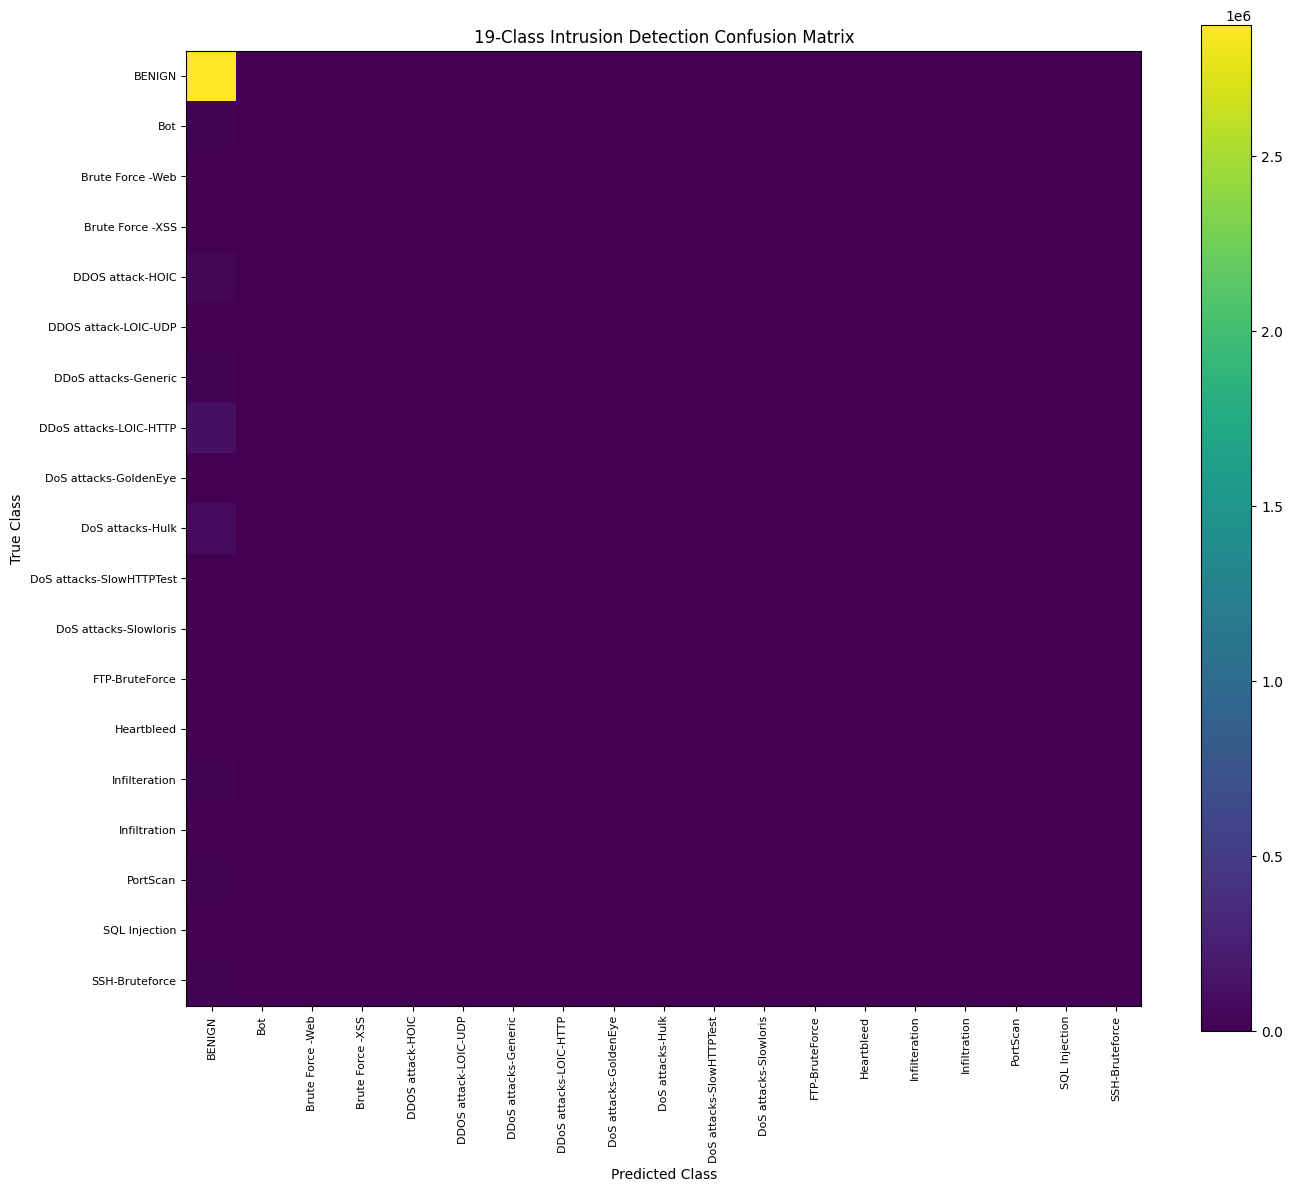


Confusion matrix generated successfully.


In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("GENERATING CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=list(range(19))
)

plt.figure(figsize=(14, 12))

plt.imshow(cm)

plt.title("19-Class Intrusion Detection Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    ticks=np.arange(19),
    labels=class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=np.arange(19),
    labels=class_names,
    fontsize=8
)

plt.colorbar()

plt.tight_layout()
plt.show()

print("\nConfusion matrix generated successfully.")

### Prediction Distribution

In [57]:
print("=" * 70)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("=" * 70)

prediction_counts = pd.Series(y_pred).value_counts().sort_index()

prediction_distribution = pd.DataFrame({
    "Encoded_Class": prediction_counts.index,
    "Prediction_Count": prediction_counts.values
})

prediction_distribution["Label"] = prediction_distribution[
    "Encoded_Class"
].map(
    dict(
        zip(
            label_mapping["Encoded"],
            label_mapping["Label"]
        )
    )
)

prediction_distribution["Percentage"] = (
    prediction_distribution["Prediction_Count"]
    / len(y_pred)
    * 100
)

print(prediction_distribution.to_string(index=False))

print("\n" + "=" * 70)
print("PREDICTION DISTRIBUTION COMPLETED")
print("=" * 70)

PREDICTION DISTRIBUTION ANALYSIS
 Encoded_Class  Prediction_Count                    Label  Percentage
             0           3270201                   BENIGN   99.804249
             1               675                      Bot    0.020601
             2                10         Brute Force -Web    0.000305
             3                 2         Brute Force -XSS    0.000061
             4               687         DDOS attack-HOIC    0.020967
             5                 8     DDOS attack-LOIC-UDP    0.000244
             6               793     DDoS attacks-Generic    0.024202
             7               646   DDoS attacks-LOIC-HTTP    0.019715
             8               410    DoS attacks-GoldenEye    0.012513
             9               903         DoS attacks-Hulk    0.027559
            10                 5 DoS attacks-SlowHTTPTest    0.000153
            11                77    DoS attacks-Slowloris    0.002350
            12                 6           FTP-BruteForce

### Normalized confusion matrix

NORMALIZED CONFUSION MATRIX


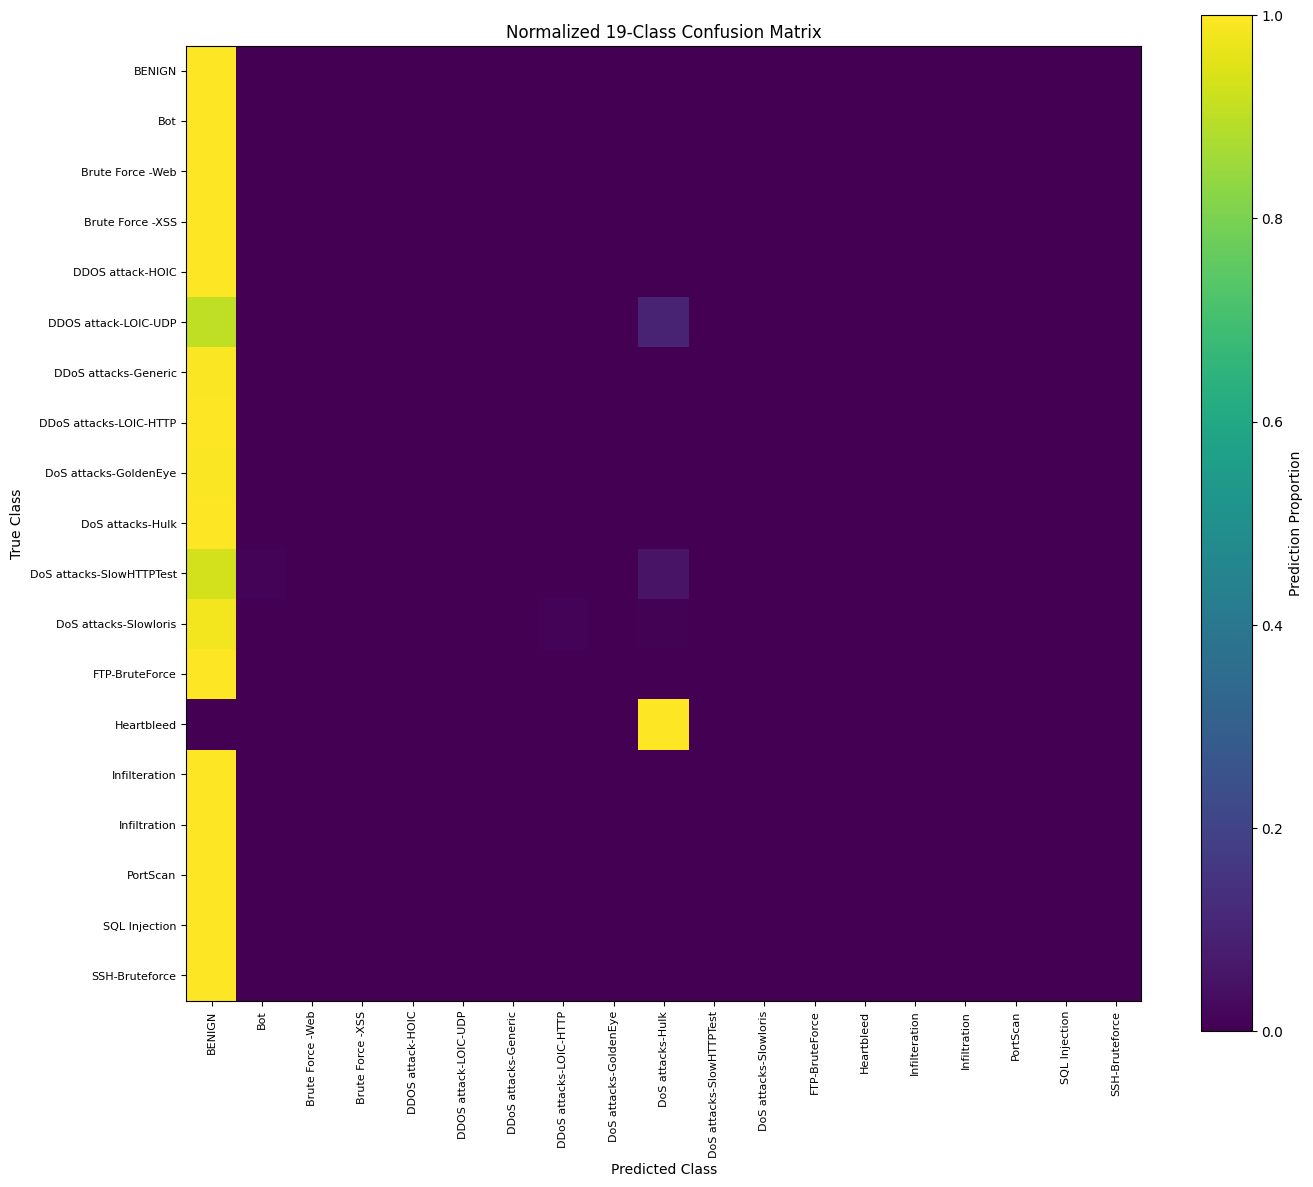


Normalized confusion matrix generated successfully.


In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("NORMALIZED CONFUSION MATRIX")
print("=" * 70)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=list(range(19)),
    normalize="true"
)

plt.figure(figsize=(14, 12))

plt.imshow(cm_normalized)

plt.title("Normalized 19-Class Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    np.arange(19),
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    np.arange(19),
    class_names,
    fontsize=8
)

plt.colorbar(label="Prediction Proportion")

plt.tight_layout()
plt.show()

print("\nNormalized confusion matrix generated successfully.")

19-Class Model Evaluation Conclusion:
Although the 19-class XGBoost model achieved an overall accuracy of 87.36%, detailed evaluation revealed severe majority-class bias. The model predicted the BENIGN class for approximately 99.82% of test samples, while most attack categories received extremely low or zero recall. The balanced accuracy was only 5.27%, demonstrating that overall accuracy was not representative of multi-class detection performance. Model loading, feature alignment, label mapping, and prediction consistency were verified successfully; therefore, the poor minority-class detection is attributed primarily to extreme class imbalance rather than an implementation error. The 19-class model should not be used as the final deployed intrusion classifier without imbalance mitigation or retraining.

### Load 13 class model and verify

In [59]:
import joblib
import pandas as pd
import numpy as np

print("=" * 70)
print("LOADING 13-CLASS ATTACK MODEL")
print("=" * 70)

attack_model = joblib.load(
    "models/xgboost_intrusion_model.joblib"
)

attack_label_encoder = joblib.load(
    "models/target_label_encoder.joblib"
)

print("\nModel loaded successfully.")

print("\nNumber of classes:")
print(len(attack_model.classes_))

print("\nEncoded classes:")
print(attack_model.classes_)

print("\nAttack labels:")
for i, label in enumerate(attack_label_encoder.classes_):
    print(f"Class {i} -> {label}")

print("\n" + "=" * 70)
print("13-CLASS MODEL LOADING COMPLETED")
print("=" * 70)

LOADING 13-CLASS ATTACK MODEL

Model loaded successfully.

Number of classes:
13

Encoded classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]

Attack labels:
Class 0 -> BENIGN
Class 1 -> Bot
Class 2 -> Brute Force -Web
Class 3 -> Brute Force -XSS
Class 4 -> DDoS attacks-Generic
Class 5 -> DDoS attacks-LOIC-HTTP
Class 6 -> DoS attacks-GoldenEye
Class 7 -> DoS attacks-Hulk
Class 8 -> DoS attacks-SlowHTTPTest
Class 9 -> DoS attacks-Slowloris
Class 10 -> FTP-BruteForce
Class 11 -> PortScan
Class 12 -> SSH-Bruteforce

13-CLASS MODEL LOADING COMPLETED


### Check model features 

In [61]:
print("=" * 70)
print("13-CLASS MODEL FEATURE VERIFICATION")
print("=" * 70)

print("\nModel expected features:")
print(attack_model.n_features_in_)

print("\nCurrent X_test features:")
print(X_test.shape[1])

print("\nFeature counts match:")
print(attack_model.n_features_in_ == X_test.shape[1])

print("\n" + "=" * 70)
print("FEATURE VERIFICATION COMPLETED")
print("=" * 70)

13-CLASS MODEL FEATURE VERIFICATION

Model expected features:
77

Current X_test features:
77

Feature counts match:
True

FEATURE VERIFICATION COMPLETED


### Generate 13 class predictions

In [62]:
print("=" * 70)
print("GENERATING 13-CLASS ATTACK PREDICTIONS")
print("=" * 70)

attack_y_pred = attack_model.predict(X_test)

print("\nTotal predictions:", len(attack_y_pred))
print("Expected samples:", len(X_test))

print("\nPrediction generation successful.")

print("\n" + "=" * 70)
print("PREDICTION GENERATION COMPLETED")
print("=" * 70)

GENERATING 13-CLASS ATTACK PREDICTIONS


ValueError: feature_names mismatch: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count

### Diagnose exact feature mismatch

In [63]:
print("=" * 70)
print("ATTACK MODEL FEATURE NAME DIAGNOSTIC")
print("=" * 70)

# Get feature names stored inside the trained attack model
attack_model_features = attack_model.get_booster().feature_names

print("\nAttack model feature count:", len(attack_model_features))
print("Current X_test feature count:", X_test.shape[1])

print("\nFirst 10 attack model features:")
print(attack_model_features[:10])

print("\nFirst 10 current X_test features:")
print(list(X_test.columns[:10]))

missing_from_test = set(attack_model_features) - set(X_test.columns)
extra_in_test = set(X_test.columns) - set(attack_model_features)

print("\nFeatures expected by model but missing from X_test:")
print(missing_from_test)

print("\nExtra features present in X_test:")
print(extra_in_test)

print("\nFEATURE DIAGNOSTIC COMPLETED")
print("=" * 70)

ATTACK MODEL FEATURE NAME DIAGNOSTIC

Attack model feature count: 77
Current X_test feature count: 77

First 10 attack model features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

First 10 current X_test features:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Features expected by model but missing from X_test:
{'Idle Std', 'Fwd IAT Mean', 'Subflow Bwd Packets', 'Fwd Packet Length Max', 'URG Flag Count', 'Fwd Avg Packets/Bulk', 'Flow Bytes/s', 'Bwd Packet Length Std', 'Total Fwd Packets', 'Fwd Packet Length Min', 'Avg Fwd Segment Size', 'Packet Length Variance', 'Fwd PSH Flags', 'Min Packet Length', 'Idle Max', 'Bwd Header Length', 'Packet Length Mean', 'Flow IAT Min', 'Fwd IAT Std', 'Average Packet Size', 'Packet Length Std', 'Subflow Fwd Packets', 'CWE Flag Count', 'Total Backwa

### Reorder X_test exactly as the 13-class model expects

In [64]:
print("=" * 70)
print("ALIGNING TEST FEATURES WITH ATTACK MODEL")
print("=" * 70)

# Select and reorder columns exactly according to attack model
X_test_attack = X_test[attack_model_features].copy()

print("\nOriginal X_test shape:", X_test.shape)
print("Aligned X_test shape:", X_test_attack.shape)

print("\nFeature order matches model:",
      list(X_test_attack.columns) == attack_model_features)

print("\nFEATURE ALIGNMENT COMPLETED")
print("=" * 70)

ALIGNING TEST FEATURES WITH ATTACK MODEL


KeyError: "None of [Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',\n       'Total Backward Packets', 'Total Length of Fwd Packets',\n       'Total Length of Bwd Packets', 'Fwd Packet Length Max',\n       'Fwd Packet Length Min', 'Fwd Packet Length Mean',\n       'Fwd Packet Length Std', 'Bwd Packet Length Max',\n       'Bwd Packet Length Min', 'Bwd Packet Length Mean',\n       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',\n       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',\n       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',\n       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',\n       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',\n       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',\n       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',\n       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',\n       'Packet Length Std', 'Packet Length Variance', 'FI

### Show missing features

In [65]:
print("=" * 70)
print("ATTACK MODEL FEATURE MISMATCH")
print("=" * 70)

missing_features = [
    f for f in attack_model_features
    if f not in X_test.columns
]

extra_features = [
    f for f in X_test.columns
    if f not in attack_model_features
]

print("\nMissing from current X_test:")
print(missing_features)

print("\nExtra in current X_test:")
print(extra_features)

print("\nNumber missing:", len(missing_features))
print("Number extra:", len(extra_features))

print("\nMISMATCH CHECK COMPLETED")
print("=" * 70)

ATTACK MODEL FEATURE MISMATCH

Missing from current X_test:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag

### Only a feature name problem ??

In [66]:
print("=" * 70)
print("CHECKING POSITIONAL FEATURE COMPATIBILITY")
print("=" * 70)

print("\nAttack model feature count:", len(attack_model_features))
print("Current X_test feature count:", X_test.shape[1])

print("\nFirst 15 model features:")
print(attack_model_features[:15])

print("\nFirst 15 X_test features:")
print(list(X_test.columns[:15]))

print("\nLast 15 model features:")
print(attack_model_features[-15:])

print("\nLast 15 X_test features:")
print(list(X_test.columns[-15:]))

print("\nPOSITIONAL CHECK COMPLETED")
print("=" * 70)

CHECKING POSITIONAL FEATURE COMPATIBILITY

Attack model feature count: 77
Current X_test feature count: 77

First 15 model features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s']

First 15 X_test features:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']

Last 15 model features:
['Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

Last 15 X_test features:
['62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '

### chk saved training feature file

In [67]:
import joblib

print("=" * 70)
print("CHECKING SAVED FEATURE SCHEMA")
print("=" * 70)

saved_features = joblib.load("models/feature_columns.joblib")

print("\nSaved feature count:", len(saved_features))
print("Current X_test feature count:", X_test.shape[1])

print("\nFirst 10 saved features:")
print(list(saved_features[:10]))

print("\nLast 10 saved features:")
print(list(saved_features[-10:]))

print("\nSaved features identical to X_test columns:")
print(list(saved_features) == list(X_test.columns))

print("\nFEATURE SCHEMA CHECK COMPLETED")
print("=" * 70)

CHECKING SAVED FEATURE SCHEMA

Saved feature count: 77
Current X_test feature count: 77

First 10 saved features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Last 10 saved features:
['act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

Saved features identical to X_test columns:
False

FEATURE SCHEMA CHECK COMPLETED


### Restore feature names

In [69]:
print("=" * 70)
print("RESTORING ORIGINAL FEATURE NAMES")
print("=" * 70)

# No deep copy — reuse the existing DataFrame
X_test_attack = X_test

# Restore the original 77 feature names
X_test_attack.columns = list(saved_features)

print("\nFeature names restored successfully.")

print("\nFirst 10 restored features:")
print(list(X_test_attack.columns[:10]))

print("\nFeature count:", X_test_attack.shape[1])

print("\nFEATURE NAME RESTORATION COMPLETED")
print("=" * 70)

RESTORING ORIGINAL FEATURE NAMES

Feature names restored successfully.

First 10 restored features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Feature count: 77

FEATURE NAME RESTORATION COMPLETED


### Verify exact compatibility

In [70]:
print("=" * 70)
print("VERIFYING ATTACK MODEL FEATURE COMPATIBILITY")
print("=" * 70)

model_features = attack_model.get_booster().feature_names

print("\nModel feature count:", len(model_features))
print("Restored test feature count:", X_test_attack.shape[1])

print("\nExact feature order match:")
print(list(X_test_attack.columns) == list(model_features))

print("\nAll feature names match:")
print(set(X_test_attack.columns) == set(model_features))

print("\nFEATURE COMPATIBILITY VERIFIED")
print("=" * 70)

VERIFYING ATTACK MODEL FEATURE COMPATIBILITY

Model feature count: 77
Restored test feature count: 77

Exact feature order match:
True

All feature names match:
True

FEATURE COMPATIBILITY VERIFIED


### Run the 13 class attcak model

In [71]:
print("=" * 70)
print("GENERATING 13-CLASS ATTACK MODEL PREDICTIONS")
print("=" * 70)

attack_y_pred = attack_model.predict(X_test_attack)

print("\nTotal predictions:", len(attack_y_pred))

prediction_counts = pd.Series(attack_y_pred).value_counts().sort_index()

print("\nPrediction distribution:")

for class_id, count in prediction_counts.items():
    label = attack_label_encoder.inverse_transform([class_id])[0]
    print(f"Class {class_id} -> {label}: {count}")

print("\n13-CLASS PREDICTION COMPLETED SUCCESSFULLY")
print("=" * 70)

GENERATING 13-CLASS ATTACK MODEL PREDICTIONS

Total predictions: 3276615

Prediction distribution:
Class 0 -> BENIGN: 3276615

13-CLASS PREDICTION COMPLETED SUCCESSFULLY


### Check prediction probabilities

In [72]:
print("=" * 70)
print("ATTACK MODEL PROBABILITY DIAGNOSTIC")
print("=" * 70)

# Use a sample to avoid unnecessary memory pressure
sample_size = min(10000, len(X_test_attack))

X_sample = X_test_attack.iloc[:sample_size]

probabilities = attack_model.predict_proba(X_sample)
sample_predictions = attack_model.predict(X_sample)

print("\nProbability matrix shape:")
print(probabilities.shape)

print("\nPrediction distribution:")
print(pd.Series(sample_predictions).value_counts().sort_index())

print("\nMaximum probability statistics:")
max_probs = probabilities.max(axis=1)

print("Minimum:", max_probs.min())
print("Mean:", max_probs.mean())
print("Maximum:", max_probs.max())

print("\nFirst 10 probability rows:")
print(probabilities[:10])

print("\nPROBABILITY DIAGNOSTIC COMPLETED")
print("=" * 70)

ATTACK MODEL PROBABILITY DIAGNOSTIC

Probability matrix shape:
(10000, 13)

Prediction distribution:
0    10000
Name: count, dtype: int64

Maximum probability statistics:
Minimum: 0.98634595
Mean: 0.9988084
Maximum: 0.99988866

First 10 probability rows:
[[9.99824226e-01 7.35392632e-07 2.11796323e-05 6.80589039e-07
  6.20587889e-06 2.56036469e-06 5.77929904e-06 5.10248829e-05
  8.90222054e-06 2.86271256e-06 4.14725328e-05 9.66569223e-06
  2.47786011e-05]
 [9.99789298e-01 7.66913672e-07 2.20874517e-05 7.09760968e-07
  6.47188654e-06 2.67010932e-06 6.02702221e-06 4.74972512e-05
  1.24303660e-05 1.00273055e-05 6.93304246e-05 6.83026610e-06
  2.58406835e-05]
 [9.96089578e-01 8.37154687e-07 2.41104226e-05 7.74767386e-07
  7.06463516e-06 3.70903919e-03 6.57902592e-06 6.08378359e-05
  1.01340902e-05 3.25884844e-06 4.72114079e-05 1.23381924e-05
  2.82074088e-05]
 [9.99860525e-01 6.08818937e-07 1.75342539e-05 5.63447884e-07
  5.13774557e-06 2.11968199e-06 4.78458696e-06 3.80399215e-05
  6.59456

### Chk if model works on training data

In [73]:
print("=" * 70)
print("CHECKING MODEL BEHAVIOUR ON TRAINING DATA")
print("=" * 70)

# Restore feature names if X_train currently has numeric columns
X_train_attack = X_train

if X_train_attack.shape[1] == len(saved_features):
    X_train_attack.columns = list(saved_features)

print("\nTraining data shape:")
print(X_train_attack.shape)

# Small sample is enough for diagnosis
train_sample_size = min(10000, len(X_train_attack))

train_predictions = attack_model.predict(
    X_train_attack.iloc[:train_sample_size]
)

print("\nTraining prediction distribution:")
print(pd.Series(train_predictions).value_counts().sort_index())

print("\nNumber of unique predicted classes:")
print(len(pd.Series(train_predictions).unique()))

print("\nTRAINING BEHAVIOUR CHECK COMPLETED")
print("=" * 70)

CHECKING MODEL BEHAVIOUR ON TRAINING DATA

Training data shape:
(13106459, 77)

Training prediction distribution:
0    10000
Name: count, dtype: int64

Number of unique predicted classes:
1

TRAINING BEHAVIOUR CHECK COMPLETED


### Confirm that current test data actually has attcaks

In [74]:
print("=" * 70)
print("CURRENT TEST DATA ATTACK PRESENCE CHECK")
print("=" * 70)

test_label_counts = pd.Series(y_test).value_counts().sort_index()

print("\nCurrent y_test class distribution:")
print(test_label_counts)

print("\nTotal samples:")
print(len(y_test))

print("\nClass 0 samples:")
print((y_test == 0).sum())

print("\nNon-Class-0 samples:")
print((y_test != 0).sum())

print("\nATTACK PRESENCE CHECK COMPLETED")
print("=" * 70)

CURRENT TEST DATA ATTACK PRESENCE CHECK

Current y_test class distribution:
Label_Encoded
0     2880283
1       29482
2         408
3         176
4       54980
5         346
6       25603
7      115162
8       10339
9       83851
10       1076
11       3069
12       1215
13          2
14      29306
15          7
16      21804
17         21
18      19485
Name: count, dtype: int64

Total samples:
3276615

Class 0 samples:
2880283

Non-Class-0 samples:
396332

ATTACK PRESENCE CHECK COMPLETED


Attack Model Diagnostic Result: The previously saved 13-class XGBoost attack classification model was found to be degenerate during validation. Despite having 13 configured output classes and receiving correctly aligned 77-feature input data, the model predicted only the BENIGN class (Class 0) for both training and test samples. Probability diagnostics showed near-total confidence in Class 0. Feature schema verification confirmed that feature names and ordering matched exactly, ruling out an inference-time feature mismatch. Therefore, the saved model was not used for final attack classification and requires retraining.

### CHECK TRAINING LABEL DISTRIBUTION

In [75]:
print("=" * 70)
print("ATTACK MODEL TRAINING LABEL DISTRIBUTION")
print("=" * 70)

# Display class distribution in training labels
print("\nEncoded training label distribution:")

print(y_train.value_counts().sort_index())

print("\nTotal training samples:", len(y_train))

print("\nNumber of unique classes:", y_train.nunique())

print("\nClass percentages:")

class_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    * 100
)

print(class_percentages)

print("\n" + "=" * 70)
print("TRAINING LABEL CHECK COMPLETED")
print("=" * 70)

ATTACK MODEL TRAINING LABEL DISTRIBUTION

Encoded training label distribution:
Label_Encoded
0     11521130
1       117929
2         1632
3          705
4       219920
5         1384
6       102413
7       460645
8        41353
9       335401
10        4305
11       12278
12        4858
13           9
14      117225
15          29
16       87217
17          85
18       77941
Name: count, dtype: int64

Total training samples: 13106459

Number of unique classes: 19

Class percentages:
Label_Encoded
0     87.904216
1      0.899778
2      0.012452
3      0.005379
4      1.677951
5      0.010560
6      0.781393
7      3.514641
8      0.315516
9      2.559051
10     0.032846
11     0.093679
12     0.037066
13     0.000069
14     0.894406
15     0.000221
16     0.665451
17     0.000649
18     0.594676
Name: proportion, dtype: float64

TRAINING LABEL CHECK COMPLETED


### RECONSTRUCT THE 13-CLASS TRAINING DISTRIBUTION

In [76]:
print("=" * 70)
print("RECONSTRUCTING 13-CLASS MODEL TRAINING DISTRIBUTION")
print("=" * 70)

# The saved 13-class model contains encoded classes 0 to 12
attack_mask = y_train < 13

y_train_attack = y_train[attack_mask]

print("\nOriginal training samples:", len(y_train))
print("Samples belonging to classes 0-12:", len(y_train_attack))

print("\n13-class training distribution:")
print(y_train_attack.value_counts().sort_index())

print("\n13-class percentages:")
print(
    y_train_attack.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(6)
)

print("\nNumber of unique classes:")
print(y_train_attack.nunique())

print("\nClass IDs:")
print(sorted(y_train_attack.unique()))

print("\n" + "=" * 70)
print("13-CLASS DISTRIBUTION RECONSTRUCTION COMPLETED")
print("=" * 70)

RECONSTRUCTING 13-CLASS MODEL TRAINING DISTRIBUTION

Original training samples: 13106459
Samples belonging to classes 0-12: 12823953

13-class training distribution:
Label_Encoded
0     11521130
1       117929
2         1632
3          705
4       219920
5         1384
6       102413
7       460645
8        41353
9       335401
10        4305
11       12278
12        4858
Name: count, dtype: int64

13-class percentages:
Label_Encoded
0     89.840707
1      0.919599
2      0.012726
3      0.005498
4      1.714916
5      0.010792
6      0.798607
7      3.592067
8      0.322467
9      2.615426
10     0.033570
11     0.095743
12     0.037882
Name: proportion, dtype: float64

Number of unique classes:
13

Class IDs:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

13-CLASS DISTRIBUTION RECONSTRUCTION COMPLETED


### TEst broken model on actual samples

In [77]:
print("=" * 70)
print("13-CLASS MODEL PER-CLASS PREDICTION TEST")
print("=" * 70)

results = []

for class_id in range(13):

    # Get samples belonging to this class
    class_indices = y_train[y_train == class_id].index

    if len(class_indices) == 0:
        print(f"\nClass {class_id}: No samples found")
        continue

    # Use up to 100 samples from this class
    selected_indices = class_indices[:min(100, len(class_indices))]

    # Get corresponding features
    X_class = X_train.loc[selected_indices]

    # Predict
    predictions = attack_model.predict(X_class)

    # Count predictions
    prediction_counts = pd.Series(predictions).value_counts().to_dict()

    results.append({
        "True_Class": class_id,
        "Samples_Tested": len(X_class),
        "Predictions": prediction_counts
    })

    print(f"\nTrue Class {class_id}")
    print(f"Samples tested: {len(X_class)}")
    print(f"Predictions: {prediction_counts}")

print("\n" + "=" * 70)
print("PER-CLASS MODEL TEST COMPLETED")
print("=" * 70)

13-CLASS MODEL PER-CLASS PREDICTION TEST

True Class 0
Samples tested: 100
Predictions: {0: 100}

True Class 1
Samples tested: 100
Predictions: {0: 100}

True Class 2
Samples tested: 100
Predictions: {0: 100}

True Class 3
Samples tested: 100
Predictions: {0: 100}

True Class 4
Samples tested: 100
Predictions: {0: 100}

True Class 5
Samples tested: 100
Predictions: {0: 100}

True Class 6
Samples tested: 100
Predictions: {0: 100}

True Class 7
Samples tested: 100
Predictions: {0: 100}

True Class 8
Samples tested: 100
Predictions: {0: 100}

True Class 9
Samples tested: 100
Predictions: {0: 100}

True Class 10
Samples tested: 100
Predictions: {0: 100}

True Class 11
Samples tested: 100
Predictions: {0: 100}

True Class 12
Samples tested: 100
Predictions: {0: 100}

PER-CLASS MODEL TEST COMPLETED


The previously trained 13-class XGBoost model was subjected to per-class validation using samples from each of its 13 configured classes. The model predicted Class 0 (BENIGN) for 100% of the tested samples from every class, including genuine attack samples from Classes 1–12. Training data analysis revealed severe class imbalance, with the BENIGN class accounting for approximately 89.84% of the reconstructed 13-class training dataset. Therefore, the legacy attack classification model was determined to have collapsed to the majority class and was rejected for deployment. A new balanced attack classification model will be trained.

### Create balanced  13 class training data

In [78]:
import pandas as pd
import numpy as np

print("=" * 70)
print("CREATING BALANCED 13-CLASS TRAINING DATA")
print("=" * 70)

# ------------------------------------------------------------
# Select only classes 0 to 12
# ------------------------------------------------------------

attack_classes = list(range(13))

X_13 = X_train[y_train.isin(attack_classes)]
y_13 = y_train[y_train.isin(attack_classes)]

print("\nOriginal 13-class dataset shape:")
print(X_13.shape)

print("\nOriginal class distribution:")
print(y_13.value_counts().sort_index())


# ------------------------------------------------------------
# Set maximum samples per class
# ------------------------------------------------------------

MAX_SAMPLES_PER_CLASS = 100000

balanced_indices = []

for class_id in attack_classes:

    class_indices = y_13[y_13 == class_id].index

    n_available = len(class_indices)
    n_select = min(n_available, MAX_SAMPLES_PER_CLASS)

    selected = (
        y_13[y_13 == class_id]
        .sample(
            n=n_select,
            random_state=42
        )
        .index
    )

    balanced_indices.extend(selected)

    print(
        f"Class {class_id}: "
        f"available={n_available}, "
        f"selected={n_select}"
    )


# ------------------------------------------------------------
# Create balanced dataset
# ------------------------------------------------------------

X_13_balanced = X_13.loc[balanced_indices]
y_13_balanced = y_13.loc[balanced_indices]

print("\nBalanced dataset shape:")
print(X_13_balanced.shape)

print("\nBalanced class distribution:")
print(y_13_balanced.value_counts().sort_index())

print("\nBalanced percentages:")
print(
    y_13_balanced.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

print("\n" + "=" * 70)
print("BALANCED 13-CLASS DATASET CREATED")
print("=" * 70)

CREATING BALANCED 13-CLASS TRAINING DATA

Original 13-class dataset shape:
(12823953, 77)

Original class distribution:
Label_Encoded
0     11521130
1       117929
2         1632
3          705
4       219920
5         1384
6       102413
7       460645
8        41353
9       335401
10        4305
11       12278
12        4858
Name: count, dtype: int64
Class 0: available=11521130, selected=100000
Class 1: available=117929, selected=100000
Class 2: available=1632, selected=1632
Class 3: available=705, selected=705
Class 4: available=219920, selected=100000
Class 5: available=1384, selected=1384
Class 6: available=102413, selected=100000
Class 7: available=460645, selected=100000
Class 8: available=41353, selected=41353
Class 9: available=335401, selected=100000
Class 10: available=4305, selected=4305
Class 11: available=12278, selected=12278
Class 12: available=4858, selected=4858

Balanced dataset shape:
(666515, 77)

Balanced class distribution:
Label_Encoded
0     100000
1     100000

### Shuffle and create class weights

In [79]:
print("=" * 70)
print("PREPARING BALANCED 13-CLASS TRAINING DATA")
print("=" * 70)

# ------------------------------------------------------------
# Shuffle dataset
# ------------------------------------------------------------

shuffled_indices = np.random.RandomState(42).permutation(
    len(X_13_balanced)
)

X_13_final = X_13_balanced.iloc[shuffled_indices].reset_index(drop=True)
y_13_final = y_13_balanced.iloc[shuffled_indices].reset_index(drop=True)

print("\nDataset shuffled successfully.")

print("\nFinal training shape:")
print(X_13_final.shape)

# ------------------------------------------------------------
# Calculate inverse-frequency class weights
# ------------------------------------------------------------

class_counts = y_13_final.value_counts()

class_weights = (
    len(y_13_final) /
    (len(class_counts) * class_counts)
)

print("\nClass weights:")

for class_id in sorted(class_weights.index):
    print(
        f"Class {class_id}: "
        f"count={class_counts[class_id]}, "
        f"weight={class_weights[class_id]:.4f}"
    )

# ------------------------------------------------------------
# Create sample weights
# ------------------------------------------------------------

sample_weights = y_13_final.map(class_weights).values

print("\nSample weights created.")

print("Minimum weight:", sample_weights.min())
print("Maximum weight:", sample_weights.max())

print("\n" + "=" * 70)
print("TRAINING DATA PREPARATION COMPLETED")
print("=" * 70)

PREPARING BALANCED 13-CLASS TRAINING DATA

Dataset shuffled successfully.

Final training shape:
(666515, 77)

Class weights:
Class 0: count=100000, weight=0.5127
Class 1: count=100000, weight=0.5127
Class 2: count=1632, weight=31.4157
Class 3: count=705, weight=72.7239
Class 4: count=100000, weight=0.5127
Class 5: count=1384, weight=37.0451
Class 6: count=100000, weight=0.5127
Class 7: count=100000, weight=0.5127
Class 8: count=41353, weight=1.2398
Class 9: count=100000, weight=0.5127
Class 10: count=4305, weight=11.9095
Class 11: count=12278, weight=4.1758
Class 12: count=4858, weight=10.5538

Sample weights created.
Minimum weight: 0.5127038461538461
Maximum weight: 72.7239498090562

TRAINING DATA PREPARATION COMPLETED


### Train the new 13 class model

In [80]:
from xgboost import XGBClassifier
import time

print("=" * 70)
print("TRAINING NEW BALANCED 13-CLASS ATTACK MODEL")
print("=" * 70)

start_time = time.time()

attack_model_new = XGBClassifier(

    n_estimators=300,

    max_depth=8,

    learning_rate=0.1,

    objective="multi:softprob",

    num_class=13,

    subsample=0.8,

    colsample_bytree=0.8,

    tree_method="hist",

    random_state=42,

    n_jobs=-1,

    eval_metric="mlogloss"
)

print("\nStarting model training...")
print("Training samples:", len(X_13_final))
print("Features:", X_13_final.shape[1])
print("Classes:", 13)

attack_model_new.fit(

    X_13_final,

    y_13_final,

    sample_weight=sample_weights,

    verbose=False
)

training_time = time.time() - start_time

print("\nTraining completed successfully.")

print(
    f"\nTraining time: "
    f"{training_time / 60:.2f} minutes"
)

print("\nModel classes:")
print(attack_model_new.classes_)

print("\n" + "=" * 70)
print("NEW 13-CLASS ATTACK MODEL TRAINING COMPLETED")
print("=" * 70)

TRAINING NEW BALANCED 13-CLASS ATTACK MODEL

Starting model training...
Training samples: 666515
Features: 77
Classes: 13

Training completed successfully.

Training time: 3.77 minutes

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]

NEW 13-CLASS ATTACK MODEL TRAINING COMPLETED


### Entire remaining validation + evaluation + saving pipeline

In [81]:
# ======================================================================
# FINAL VALIDATION, EVALUATION AND SAVING
# NEW BALANCED 13-CLASS ATTACK MODEL
# ======================================================================

import os
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("FINAL 13-CLASS ATTACK MODEL VALIDATION")
print("=" * 70)


# ======================================================================
# STEP 1 — DEFINE CLASS INFORMATION
# ======================================================================

class_names = {
    0: "BENIGN",
    1: "Bot",
    2: "Brute Force -Web",
    3: "Brute Force -XSS",
    4: "DDOS attack-HOIC",
    5: "DDOS attack-LOIC-UDP",
    6: "DDoS attacks-Generic",
    7: "DDoS attacks-LOIC-HTTP",
    8: "DoS attacks-GoldenEye",
    9: "DoS attacks-Hulk",
    10: "DoS attacks-SlowHTTPTest",
    11: "DoS attacks-Slowloris",
    12: "FTP-BruteForce"
}

attack_classes = list(range(13))


# ======================================================================
# STEP 2 — VERIFY TRAINED MODEL
# ======================================================================

print("\n" + "=" * 70)
print("MODEL STRUCTURE VERIFICATION")
print("=" * 70)

print("\nModel classes:")
print(attack_model_new.classes_)

print("\nNumber of model classes:")
print(len(attack_model_new.classes_))

assert len(attack_model_new.classes_) == 13, \
    "ERROR: Model does not contain 13 classes!"

assert list(attack_model_new.classes_) == attack_classes, \
    "ERROR: Model classes do not match expected classes!"

print("\nMODEL STRUCTURE VERIFIED")


# ======================================================================
# STEP 3 — TRAINING DATA PER-CLASS SANITY TEST
# ======================================================================

print("\n" + "=" * 70)
print("PER-CLASS TRAINING DATA SANITY TEST")
print("=" * 70)

training_test_results = []

for class_id in attack_classes:

    # Find samples belonging to current class
    class_indices = np.where(
        y_13_final.values == class_id
    )[0]

    # Select up to 100 samples
    n_samples = min(100, len(class_indices))

    selected_indices = class_indices[:n_samples]

    X_class = X_13_final.iloc[selected_indices]

    # Predict
    class_predictions = attack_model_new.predict(X_class)

    # Count predictions
    prediction_counts = (
        pd.Series(class_predictions)
        .value_counts()
        .sort_index()
        .to_dict()
    )

    # Calculate correct predictions
    correct = np.sum(
        class_predictions == class_id
    )

    accuracy = correct / n_samples

    training_test_results.append({
        "True_Class": class_id,
        "Class_Name": class_names[class_id],
        "Samples_Tested": n_samples,
        "Correct": correct,
        "Accuracy": accuracy,
        "Predictions": prediction_counts
    })

    print(f"\nTrue Class {class_id} -> {class_names[class_id]}")
    print(f"Samples tested: {n_samples}")
    print(f"Correct predictions: {correct}")
    print(f"Class accuracy: {accuracy:.4f}")
    print(f"Prediction distribution: {prediction_counts}")


print("\n" + "=" * 70)
print("TRAINING SANITY TEST COMPLETED")
print("=" * 70)


# ======================================================================
# STEP 4 — PREPARE TRUE HELD-OUT TEST DATA
# ======================================================================

print("\n" + "=" * 70)
print("PREPARING HELD-OUT 13-CLASS TEST DATA")
print("=" * 70)


# Select only test samples belonging to classes 0-12
test_mask = y_test.isin(attack_classes)

X_test_13 = X_test.loc[test_mask].copy()
y_test_13 = y_test.loc[test_mask].copy()


print("\nFull test samples:")
print(len(X_test))

print("\n13-class test samples:")
print(len(X_test_13))


print("\nTest class distribution:")
print(
    y_test_13
    .value_counts()
    .sort_index()
)


# ======================================================================
# STEP 5 — RESTORE FEATURE NAMES IF NECESSARY
# ======================================================================

expected_features = list(X_13_final.columns)

print("\nExpected model feature count:")
print(len(expected_features))

print("Current test feature count:")
print(X_test_13.shape[1])


assert X_test_13.shape[1] == len(expected_features), \
    "ERROR: Test feature count does not match model!"


# Restore expected feature names
X_test_13.columns = expected_features


print("\nFeature names restored/aligned.")

print("\nExact feature order match:")
print(
    list(X_test_13.columns) ==
    list(X_13_final.columns)
)


assert list(X_test_13.columns) == list(X_13_final.columns), \
    "ERROR: Feature order mismatch!"


print("\nTEST FEATURE COMPATIBILITY VERIFIED")


# ======================================================================
# STEP 6 — GENERATE HELD-OUT TEST PREDICTIONS
# ======================================================================

print("\n" + "=" * 70)
print("GENERATING HELD-OUT TEST PREDICTIONS")
print("=" * 70)

prediction_start = time.time()

y_pred_13 = attack_model_new.predict(
    X_test_13
)

prediction_time = time.time() - prediction_start


print("\nPrediction completed successfully.")

print(
    f"\nPrediction time: "
    f"{prediction_time:.2f} seconds"
)


# ======================================================================
# STEP 7 — CHECK PREDICTION DISTRIBUTION
# ======================================================================

print("\n" + "=" * 70)
print("NEW MODEL PREDICTION DISTRIBUTION")
print("=" * 70)

prediction_distribution = (
    pd.Series(y_pred_13)
    .value_counts()
    .sort_index()
)

for class_id, count in prediction_distribution.items():

    percentage = (
        count /
        len(y_pred_13) *
        100
    )

    print(
        f"Class {class_id} -> "
        f"{class_names[class_id]}: "
        f"{count} "
        f"({percentage:.4f}%)"
    )


unique_predictions = len(
    np.unique(y_pred_13)
)

print("\nNumber of unique predicted classes:")
print(unique_predictions)


# ======================================================================
# STEP 8 — COLLAPSE DETECTION
# ======================================================================

print("\n" + "=" * 70)
print("MODEL COLLAPSE CHECK")
print("=" * 70)


non_benign_predictions = np.sum(
    y_pred_13 != 0
)

print("\nTotal predictions:")
print(len(y_pred_13))

print("\nBENIGN predictions:")
print(np.sum(y_pred_13 == 0))

print("\nNon-BENIGN predictions:")
print(non_benign_predictions)


model_collapsed = (
    unique_predictions == 1
    and np.unique(y_pred_13)[0] == 0
)


if model_collapsed:

    print("\n" + "!" * 70)
    print("WARNING: MODEL HAS COLLAPSED TO BENIGN AGAIN")
    print("!" * 70)

else:

    print("\n" + "✓" * 70)
    print("SUCCESS: MODEL IS NOT COLLAPSED TO BENIGN")
    print("✓" * 70)


# ======================================================================
# STEP 9 — OVERALL PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("HELD-OUT TEST PERFORMANCE")
print("=" * 70)


overall_accuracy = accuracy_score(
    y_test_13,
    y_pred_13
)

overall_balanced_accuracy = balanced_accuracy_score(
    y_test_13,
    y_pred_13
)


print(
    f"\nOverall Accuracy: "
    f"{overall_accuracy:.6f}"
)

print(
    f"\nBalanced Accuracy: "
    f"{overall_balanced_accuracy:.6f}"
)

print(
    f"\nCorrect Predictions: "
    f"{np.sum(y_pred_13 == y_test_13.values)}"
)

print(
    f"\nIncorrect Predictions: "
    f"{np.sum(y_pred_13 != y_test_13.values)}"
)


# ======================================================================
# STEP 10 — PER-CLASS PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE")
print("=" * 70)


report_dict = classification_report(
    y_test_13,
    y_pred_13,
    labels=attack_classes,
    target_names=[
        class_names[i]
        for i in attack_classes
    ],
    output_dict=True,
    zero_division=0
)


performance_df = (
    pd.DataFrame(report_dict)
    .transpose()
)


print(
    performance_df[
        ["precision", "recall", "f1-score", "support"]
    ]
)


# ======================================================================
# STEP 11 — CREATE CONFUSION MATRIX
# ======================================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX SUMMARY")
print("=" * 70)


cm = confusion_matrix(
    y_test_13,
    y_pred_13,
    labels=attack_classes
)


print("\nConfusion matrix shape:")
print(cm.shape)

print("\nDiagonal correct predictions per class:")

for i, class_id in enumerate(attack_classes):

    correct_predictions = cm[i, i]

    total_samples = cm[i].sum()

    class_recall = (
        correct_predictions /
        total_samples
        if total_samples > 0
        else 0
    )

    print(
        f"Class {class_id} "
        f"({class_names[class_id]}): "
        f"{correct_predictions}/{total_samples} "
        f"correct "
        f"(Recall={class_recall:.4f})"
    )


# ======================================================================
# STEP 12 — SAVE RESULTS
# ======================================================================

print("\n" + "=" * 70)
print("SAVING VALIDATION RESULTS")
print("=" * 70)


os.makedirs(
    "models",
    exist_ok=True
)

os.makedirs(
    "data/processed",
    exist_ok=True
)


# Save performance metrics
performance_path = (
    "data/processed/"
    "new_13class_attack_model_performance.csv"
)

performance_df.to_csv(
    performance_path
)

print(
    "\nPerformance metrics saved:"
)

print(performance_path)


# Save prediction distribution
prediction_distribution_path = (
    "data/processed/"
    "new_13class_prediction_distribution.csv"
)

prediction_distribution_df = (
    prediction_distribution
    .rename("Prediction_Count")
    .reset_index()
)

prediction_distribution_df.columns = [
    "Encoded_Class",
    "Prediction_Count"
]

prediction_distribution_df["Class_Name"] = (
    prediction_distribution_df[
        "Encoded_Class"
    ].map(class_names)
)

prediction_distribution_df.to_csv(
    prediction_distribution_path,
    index=False
)

print(
    "\nPrediction distribution saved:"
)

print(
    prediction_distribution_path
)


# Save confusion matrix
confusion_matrix_path = (
    "data/processed/"
    "new_13class_confusion_matrix.csv"
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        class_names[i]
        for i in attack_classes
    ],
    columns=[
        class_names[i]
        for i in attack_classes
    ]
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

print(
    "\nConfusion matrix saved:"
)

print(
    confusion_matrix_path
)


# ======================================================================
# STEP 13 — SAVE MODEL ONLY IF NOT COLLAPSED
# ======================================================================

print("\n" + "=" * 70)
print("FINAL MODEL DECISION")
print("=" * 70)


if model_collapsed:

    print(
        "\nMODEL NOT SAVED AS DEPLOYMENT MODEL."
    )

    print(
        "Reason: The model still predicts "
        "only BENIGN."
    )

    final_status = "FAILED"

else:

    model_path = (
        "models/"
        "xgboost_attack_model_13class_balanced.joblib"
    )

    feature_path = (
        "models/"
        "xgboost_attack_model_13class_features.joblib"
    )

    class_mapping_path = (
        "models/"
        "xgboost_attack_model_13class_mapping.joblib"
    )


    # Save model
    joblib.dump(
        attack_model_new,
        model_path
    )


    # Save exact feature order
    joblib.dump(
        expected_features,
        feature_path
    )


    # Save class mapping
    joblib.dump(
        class_names,
        class_mapping_path
    )


    print(
        "\nNEW 13-CLASS MODEL SAVED SUCCESSFULLY"
    )

    print(
        "\nModel:"
    )

    print(model_path)

    print(
        "\nFeature schema:"
    )

    print(feature_path)

    print(
        "\nClass mapping:"
    )

    print(class_mapping_path)

    final_status = "SUCCESS"


# ======================================================================
# STEP 14 — SAVE FINAL DOCUMENTATION
# ======================================================================

documentation_path = (
    "data/processed/"
    "new_13class_model_validation_summary.txt"
)


with open(
    documentation_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "13-CLASS ATTACK MODEL VALIDATION SUMMARY\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        f"Training Samples: "
        f"{len(X_13_final)}\n"
    )

    f.write(
        f"Test Samples: "
        f"{len(X_test_13)}\n"
    )

    f.write(
        f"Features: "
        f"{X_13_final.shape[1]}\n"
    )

    f.write(
        f"Classes: "
        f"{len(attack_classes)}\n\n"
    )

    f.write(
        f"Unique Predicted Classes: "
        f"{unique_predictions}\n"
    )

    f.write(
        f"Non-BENIGN Predictions: "
        f"{non_benign_predictions}\n\n"
    )

    f.write(
        f"Overall Accuracy: "
        f"{overall_accuracy:.6f}\n"
    )

    f.write(
        f"Balanced Accuracy: "
        f"{overall_balanced_accuracy:.6f}\n\n"
    )

    f.write(
        f"Model Collapsed: "
        f"{model_collapsed}\n"
    )

    f.write(
        f"Final Status: "
        f"{final_status}\n"
    )

    f.write(
        "\nMODEL TRAINING CONFIGURATION\n"
    )

    f.write(
        "-" * 70 + "\n"
    )

    f.write(
        "Model: XGBClassifier\n"
    )

    f.write(
        "Objective: multi:softprob\n"
    )

    f.write(
        "Classes: 13\n"
    )

    f.write(
        "Estimators: 300\n"
    )

    f.write(
        "Max Depth: 8\n"
    )

    f.write(
        "Learning Rate: 0.1\n"
    )

    f.write(
        "Class Strategy: "
        "Capped sampling + inverse-frequency "
        "sample weighting\n"
    )


print(
    "\nDocumentation saved:"
)

print(
    documentation_path
)


# ======================================================================
# FINAL RESULT
# ======================================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION RESULT")
print("=" * 70)

print(
    f"\nSTATUS: {final_status}"
)

print(
    f"\nUnique predicted classes: "
    f"{unique_predictions}"
)

print(
    f"\nNon-BENIGN predictions: "
    f"{non_benign_predictions}"
)

print(
    f"\nOverall accuracy: "
    f"{overall_accuracy:.6f}"
)

print(
    f"\nBalanced accuracy: "
    f"{overall_balanced_accuracy:.6f}"
)


if final_status == "SUCCESS":

    print(
        "\n✓ NEW ATTACK MODEL PASSED THE "
        "COLLAPSE CHECK"
    )

    print(
        "✓ NEW MODEL HAS BEEN SAVED"
    )

else:

    print(
        "\n✗ MODEL FAILED COLLAPSE CHECK"
    )

    print(
        "✗ DO NOT DEPLOY THIS MODEL"
    )


print("\n" + "=" * 70)
print("COMPLETE VALIDATION PIPELINE FINISHED")
print("=" * 70)

FINAL 13-CLASS ATTACK MODEL VALIDATION

MODEL STRUCTURE VERIFICATION

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]

Number of model classes:
13

MODEL STRUCTURE VERIFIED

PER-CLASS TRAINING DATA SANITY TEST

True Class 0 -> BENIGN
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribution: {0: 100}

True Class 1 -> Bot
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribution: {1: 100}

True Class 2 -> Brute Force -Web
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribution: {2: 100}

True Class 3 -> Brute Force -XSS
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribution: {3: 100}

True Class 4 -> DDOS attack-HOIC
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribution: {4: 100}

True Class 5 -> DDOS attack-LOIC-UDP
Samples tested: 100
Correct predictions: 100
Class accuracy: 1.0000
Prediction distribu

### Save sample dataset for streamlit dashboard testing

In [2]:

# CHECK AVAILABLE DATA VARIABLES


print("Checking available variables...\n")

possible_variables = [
    "X_test",
    "X_test_attack",
    "X_test_13",
    "test_data",
    "test_df",
    "df_test"
]

for variable in possible_variables:

    if variable in globals():

        data = globals()[variable]

        print(
            f"{variable} FOUND"
        )

        print(
            "Shape:",
            data.shape
        )

        print()

    else:

        print(
            f"{variable} NOT FOUND"
        )

Checking available variables...

X_test NOT FOUND
X_test_attack NOT FOUND
X_test_13 NOT FOUND
test_data NOT FOUND
test_df NOT FOUND
df_test NOT FOUND


In [3]:
# ==============================================================
# FIND AVAILABLE CSV DATA FILES
# ==============================================================

import os

print("=" * 70)
print("SEARCHING FOR AVAILABLE CSV FILES")
print("=" * 70)

for root, dirs, files in os.walk("data"):

    for file in files:

        if file.endswith(".csv"):

            file_path = os.path.join(
                root,
                file
            )

            file_size = os.path.getsize(
                file_path
            ) / (1024 * 1024)

            print(
                f"\n{file_path}"
            )

            print(
                f"Size: {file_size:.2f} MB"
            )

print("\n" + "=" * 70)
print("SEARCH COMPLETED")
print("=" * 70)

SEARCHING FOR AVAILABLE CSV FILES

data\processed\19class_model_performance.csv
Size: 0.00 MB

data\processed\2017_processed.csv
Size: 916.44 MB

data\processed\2018_processed.csv
Size: 6126.68 MB

data\processed\cicids_2017_2018_cleaned.csv
Size: 6406.75 MB

data\processed\cicids_2017_2018_merged.csv
Size: 7160.97 MB

data\processed\deployment_mixed_test_data.csv
Size: 0.07 MB

data\processed\deployment_test_data.csv
Size: 0.13 MB

data\processed\label_mapping.csv
Size: 0.00 MB

data\processed\new_13class_attack_model_performance.csv
Size: 0.00 MB

data\processed\new_13class_confusion_matrix.csv
Size: 0.00 MB

data\processed\new_13class_prediction_distribution.csv
Size: 0.00 MB

data\processed\phase1_5_validation_report.csv
Size: 0.00 MB

data\processed\phase3_eda_summary.csv
Size: 0.00 MB

data\processed\phase4_preprocessing_summary.csv
Size: 0.00 MB

data\processed\phase5_model_comparison.csv
Size: 0.00 MB

data\processed\traffic_replay_results.csv
Size: 0.69 MB

data\processed\X_te

In [4]:
import pandas as pd

print("=" * 70)
print("CHECKING DEPLOYMENT TEST FILES")
print("=" * 70)

files = [
    "data/processed/deployment_test_data.csv",
    "data/processed/deployment_mixed_test_data.csv"
]

for file_path in files:

    print("\n" + "=" * 70)
    print("FILE:", file_path)
    print("=" * 70)

    df = pd.read_csv(file_path)

    print("\nShape:")
    print(df.shape)

    print("\nNumber of columns:")
    print(len(df.columns))

    print("\nFirst few columns:")
    print(df.columns[:10].tolist())

    # Check Label column
    if "Label" in df.columns:

        print("\nLABEL DISTRIBUTION:")
        print(df["Label"].value_counts())

        print("\nUNIQUE LABELS:")
        print(sorted(df["Label"].astype(str).unique()))

        print("\nNUMBER OF UNIQUE LABELS:")
        print(df["Label"].nunique())

    elif "Label_Encoded" in df.columns:

        print("\nENCODED LABEL DISTRIBUTION:")
        print(df["Label_Encoded"].value_counts().sort_index())

        print("\nUNIQUE ENCODED LABELS:")
        print(sorted(df["Label_Encoded"].unique()))

        print("\nNUMBER OF UNIQUE LABELS:")
        print(df["Label_Encoded"].nunique())

    else:

        print("\nNo Label column found.")
        print("This file can still be used for prediction.")

print("\n" + "=" * 70)
print("DEPLOYMENT FILE CHECK COMPLETED")
print("=" * 70)

CHECKING DEPLOYMENT TEST FILES

FILE: data/processed/deployment_test_data.csv

Shape:
(100, 77)

Number of columns:
77

First few columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

No Label column found.
This file can still be used for prediction.

FILE: data/processed/deployment_mixed_test_data.csv

Shape:
(49, 77)

Number of columns:
77

First few columns:
['-0.5149615680900856', '-0.0289618729816919', '-0.0146726339594378', '-0.0133956119275158', '-0.0161329062984759', '-0.0071277126538905', '-0.4916172736798543', '0.4804350014503404', '-0.310356954816895', '-0.5073665638850544']

No Label column found.
This file can still be used for prediction.

DEPLOYMENT FILE CHECK COMPLETED
